<div align="center">
  <img src="http://sct.inf.utfsm.cl/wp-content/uploads/2020/04/logo_di.png" width="70%" style="min-width: 300px; max-width: 600px;">
  <h1>INF398 - Introducción al Aprendizaje Automático</h1>
  <h3 style="color: #555;">Tarea #1</h3>
  <p>
    <strong>Tomás Donoso</strong><br>
    <em>202073591-3</em><br>
    <em>tomas.donoson@usm.cl</em>
  </p>
  <p>
    <strong>Luis Zegarra</strong><br>
    <em>202073628-6</em><br>
    <em>luis.zegarra@usm.cl</em>
  </p>
</div>

<hr>

# Declaración de uso de IA

**Asistente(s) utilizado(s) y versión:** Claude (Anthropic): Sonnet 4.6 y Opus 4.7.

**Etapa(s) en que se utilizó:** EDA, selección de atributos, modelamiento y redacción.

**Usos significativos (prompts y cómo se incorporaron):**

1. _Prompt:_ "Inspecciona el archivo `datasets_train.h5` y diagnostica la patología estadística dominante de cada dataset (régimen n vs p, multicolinealidad, no-linealidad, dependencia temporal, desbalance, outliers, alta dimensionalidad)."
   _Cómo se incorporó:_ Se usaron los diagnósticos como hipótesis iniciales (solo a modo de comparación para tener un valor proximo al cual llegar), pero cada afirmación fue re-verificada de forma independiente dentro del notebook con código propio (matrices de correlación, ACF, comparación lineal-vs-árbol, etc.). Las interpretaciones del texto son del grupo.

2. _Prompt:_ "Sugiere un esquema de validación cruzada y métrica apropiada para un dataset de regresión con dependencia temporal."
   _Cómo se incorporó:_ Se adoptó `TimeSeriesSplit` para el dataset C tras confirmar la autocorrelación nosotros mismos con `plot_acf`. Se descartaron sugerencias que no se sostuvieran con la evidencia del EDA.


3. _Prompt:_ "Mejora la redacción del siguiente fragmento para hacer el reporte como se haría en un paper: ..."
   _Cómo se incorporó:_ En base a la recomendación dada por la IA, se tomaban algunas partes para que la redacción quedara formal y con terminos técnicos que fueran necesarios a nuestro criterio.

> _Nota:_ completar/ajustar esta celda con los usos reales del grupo. La omisión cuando hubo uso de IA implica un descuento de hasta 15 puntos.

# 0. Configuración global

Fijamos una semilla global `RANDOM_STATE` que se reutiliza en **todos** los splits y modelos estocásticos
para garantizar reproducibilidad (requisito del enunciado). Importamos todo lo necesario una sola vez.

In [6]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import h5py

from statsmodels.graphics.tsaplots import plot_acf

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder

from sklearn.linear_model import (RidgeCV, LassoCV, ElasticNetCV, HuberRegressor,
                                  LogisticRegression, LogisticRegressionCV)
from sklearn.tree import (DecisionTreeClassifier, DecisionTreeRegressor,
                          plot_tree)

from sklearn.feature_selection import (f_regression, mutual_info_regression,
                                       f_classif, mutual_info_classif)
from sklearn.model_selection import (cross_val_score, cross_validate,
                                     StratifiedKFold, KFold, TimeSeriesSplit,
                                     GridSearchCV)
from sklearn.inspection import permutation_importance
from sklearn.metrics import (mean_absolute_error, r2_score, root_mean_squared_error,
                             roc_auc_score, average_precision_score, f1_score,
                             balanced_accuracy_score, confusion_matrix,
                             classification_report)

# Semilla unica para todo el notebook
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

# Carga de datasets

Cargamos el archivo `datasets_train.h5`. Cada dataset expone `X_train`, `y_train` y `X_test`.
**`X_test` no tiene etiquetas y solo se usa al final** para generar predicciones: nunca participa
del EDA ni del ajuste de modelos (evita fuga de datos, penalizada en la rúbrica).

In [7]:
def cargar_datasets_desde_h5(archivo_h5):
    datasets = {}
    with h5py.File(archivo_h5, "r") as f:
        for grupo in f:
            datasets[grupo] = {}
            for key in f[grupo]:
                datasets[grupo][key] = f[grupo][key][:]
    return datasets

# única ruta fija al dataset
datasets_train = cargar_datasets_desde_h5("datasets_train.h5")

# Resumen rapido de dimensiones y tipo de tarea
for g in sorted(datasets_train):
    X = datasets_train[g]["X_train"]
    y = datasets_train[g]["y_train"]
    Xt = datasets_train[g]["X_test"]
    tarea = "clasificacion" if y.dtype.kind in "iu" else "regresion"
    print(f"{g}: X_train={X.shape}, X_test={Xt.shape}, y={y.dtype} -> {tarea}")

A: X_train=(500000, 20), X_test=(70000, 20), y=int64 -> clasificacion
B: X_train=(500000, 15), X_test=(70000, 15), y=float32 -> regresion
C: X_train=(500000, 5), X_test=(70000, 5), y=float32 -> regresion
D: X_train=(500000, 10), X_test=(70000, 10), y=int64 -> clasificacion
E: X_train=(150, 400), X_test=(100, 400), y=float32 -> regresion
F: X_train=(500000, 10), X_test=(70000, 10), y=int64 -> clasificacion
G: X_train=(500000, 5), X_test=(70000, 5), y=float32 -> regresion
H: X_train=(500000, 10), X_test=(70000, 10), y=float32 -> regresion


# Funciones auxiliares reutilizables

Definimos helpers que usaremos en los 8 datasets, para mantener el código corto y consistente.
Todos respetan dos reglas de la rúbrica: (1) el preprocesamiento vive **dentro** del `Pipeline`,
así se ajusta solo con el train de cada fold; (2) `random_state` está fijo en todo.

In [8]:
def info_regimen(X, y):
    """Imprime el regimen (n, p) y la relacion entre ellos."""
    n, p = X.shape
    if n > 20 * p:
        regimen = "n >> p (muchas mas observaciones que features)"
    elif n >= p:
        regimen = "n > p"
    else:
        regimen = "n < p (alta dimensionalidad)"
    print(f"n = {n}, p = {p}  ->  {regimen}")
    return n, p


def detectar_tipos(X, max_niveles=15):
    """Clasifica cada columna como continua o categorica/discreta.

    Heuristica simple: si los valores son enteros y hay pocos niveles
    distintos, la tratamos como categorica.
    """
    continuas, categoricas = [], []
    for j in range(X.shape[1]):
        col = X[:, j]
        es_entera = np.allclose(col, np.round(col))
        n_niveles = len(np.unique(col))
        if es_entera and n_niveles <= max_niveles:
            categoricas.append(j)
        else:
            continuas.append(j)
    return continuas, categoricas


def ranking_filter_regresion(X, y, k=None):
    """Devuelve rankings (indices de mejor a peor) por F-test y por MI."""
    F, _ = f_regression(X, y)
    mi = mutual_info_regression(X, y, random_state=RANDOM_STATE)
    rank_F = np.argsort(F)[::-1]
    rank_mi = np.argsort(mi)[::-1]
    return rank_F, rank_mi, F, mi


def ranking_filter_clasificacion(X, y):
    """Rankings por ANOVA F y por informacion mutua para clasificacion."""
    F, _ = f_classif(X, y)
    mi = mutual_info_classif(X, y, random_state=RANDOM_STATE)
    rank_F = np.argsort(F)[::-1]
    rank_mi = np.argsort(mi)[::-1]
    return rank_F, rank_mi, F, mi


def matriz_coincidencia(rankings, nombres, k):
    """Cuenta cuantas features top-k comparten cada par de metodos."""
    tops = [set(r[:k]) for r in rankings]
    M = pd.DataFrame(index=nombres, columns=nombres, dtype=int)
    for i, a in enumerate(tops):
        for j, b in enumerate(tops):
            M.iloc[i, j] = len(a & b)
    return M


def podar_arbol_cart(estimador_base, X, y, scoring, cv):
    """Busca el mejor ccp_alpha por CV usando el camino de poda costo-complejidad.

    Devuelve el GridSearchCV ya ajustado.
    """
    path = estimador_base.cost_complexity_pruning_path(X, y)
    alphas = path.ccp_alphas
    # Toma una grilla acotada de alphas (evita valores extremos y duplicados)
    alphas = np.unique(alphas)
    alphas = alphas[alphas >= 0]
    if len(alphas) > 30:
        alphas = alphas[np.linspace(0, len(alphas) - 1, 30).astype(int)]
    grid = GridSearchCV(
        estimador_base,
        param_grid={"ccp_alpha": alphas},
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
    )
    grid.fit(X, y)
    return grid

In [9]:
# Aqui se acumulan las predicciones de test de cada dataset.
# Se escribiran al final en predicciones_T1_rol1_rol2.h5 en este mismo orden de filas.
predicciones = {}

# Dataset A

**Tipo de tarea:** clasificación binaria.

Recorremos las cuatro etapas de la metodología.

## A — Etapa 1: Análisis exploratorio de datos

Cargamos solo `X_train`, `y_train` (el `X_test` queda intacto hasta el final).

In [10]:
Xa = datasets_train["A"]["X_train"]
ya = datasets_train["A"]["y_train"]

print("=== Regimen ===")
na, pa = info_regimen(Xa, ya)

print("\n=== Tipos de variable ===")
cont_a, cat_a = detectar_tipos(Xa)
print(f"Continuas: {len(cont_a)} | Categoricas/discretas: {len(cat_a)} (indices {cat_a})")

print("\n=== Balance de clases ===")
clases, counts = np.unique(ya, return_counts=True)
print(dict(zip(clases.tolist(), counts.tolist())), "->", np.round(counts / counts.sum(), 3))

=== Regimen ===
n = 500000, p = 20  ->  n >> p (muchas mas observaciones que features)

=== Tipos de variable ===
Continuas: 20 | Categoricas/discretas: 0 (indices [])

=== Balance de clases ===
{0: 266880, 1: 233120} -> [0.534 0.466]


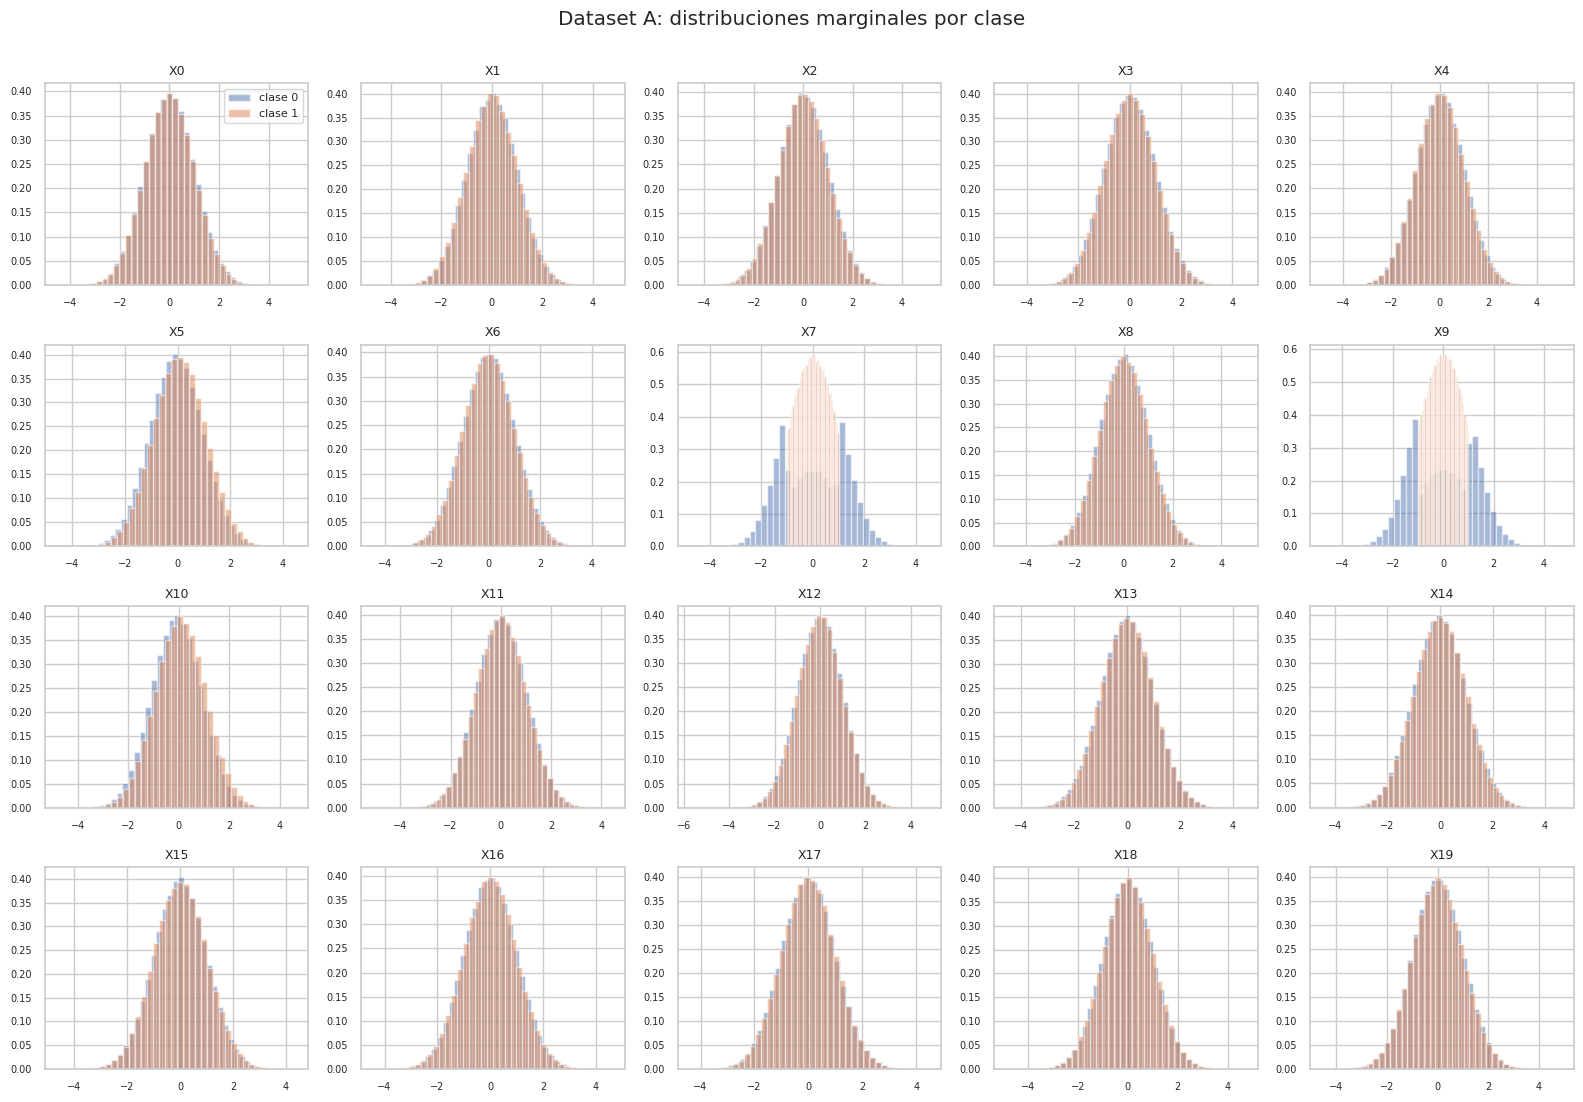

In [11]:
# Distribuciones marginales por clase: buscar si alguna feature separa las clases por si sola
fig, axes = plt.subplots(4, 5, figsize=(16, 11))
for j, ax in enumerate(axes.ravel()):
    ax.hist(Xa[ya == 0, j], bins=40, alpha=0.5, label="clase 0", density=True)
    ax.hist(Xa[ya == 1, j], bins=40, alpha=0.5, label="clase 1", density=True)
    ax.set_title(f"X{j}", fontsize=9)
    ax.tick_params(labelsize=7)
axes.ravel()[0].legend(fontsize=8)
fig.suptitle("Dataset A: distribuciones marginales por clase", y=1.0)
plt.tight_layout()
plt.show()

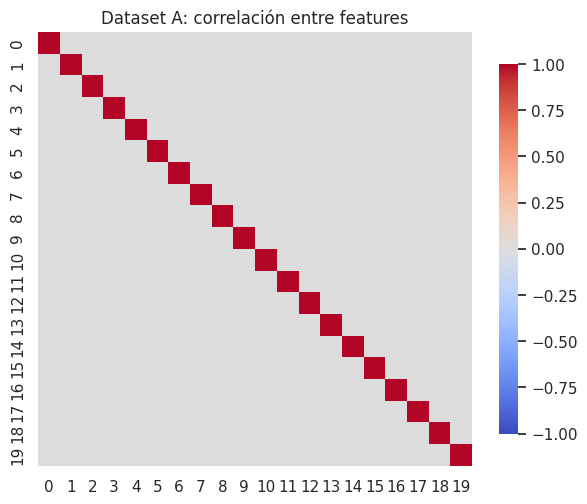

Maxima |correlacion| fuera de la diagonal: 0.007


In [12]:
# Matriz de correlacion entre features
corr_a = np.corrcoef(Xa, rowvar=False)
plt.figure(figsize=(7, 6))
sns.heatmap(corr_a, cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={"shrink": 0.8})
plt.title("Dataset A: correlación entre features")
plt.show()

print(f"Maxima |correlacion| fuera de la diagonal: {np.abs(corr_a[np.triu_indices(pa, 1)]).max():.3f}")

In [13]:
# Test rápido lineal-vs-arbol: si el árbol supera con holgura al modelo lineal, hay no-linealidad. 
# Usamos un subconjunto para que sea rápido.
idx = np.random.RandomState(RANDOM_STATE).choice(na, 30000, replace=False)
cv3 = StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE)

lin_a = Pipeline([("sc", StandardScaler()),
                  ("clf", LogisticRegression(max_iter=1000))])
arb_a = DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE)

auc_lin = cross_val_score(lin_a, Xa[idx], ya[idx], cv=cv3, scoring="roc_auc").mean()
auc_arb = cross_val_score(arb_a, Xa[idx], ya[idx], cv=cv3, scoring="roc_auc").mean()
print(f"AUC LogReg = {auc_lin:.3f}  |  AUC arbol(d=8) = {auc_arb:.3f}  |  gap = {auc_arb - auc_lin:+.3f}")

AUC LogReg = 0.553  |  AUC arbol(d=8) = 1.000  |  gap = +0.447


### A — Respuestas Etapa 1

- **E1.1 Régimen (n, p).** Estamos en $n \gg p$ (n = 500000, p = 20). Con 25.000 observaciones por feature, los modelos lineales no sufren varianza por escasez de datos; el problema, si lo hay, será de sesgo (falta de capacidad para capturar la forma de la frontera), no de sobreajuste.

- **E1.2 Supuestos del modelo lineal.**  Las 20 features son continuas, están estandarizadas y descorrelacionadas (máxima |correlación| fuera de la diagonal = 0.007), por lo que no hay multicolinealidad. El supuesto que falla es el de separabilidad lineal: las distribuciones marginales de cada feature son casi idénticas entre clases, pero se puede evidenciar una variación en X7 y X9, y aun así el árbol alcanza AUC = 1.000 mientras la regresión logística se queda en 0.553 (apenas mejor que el azar). Esto solo ocurre cuando la clase depende de interacciones entre features, no de efectos lineales individuales.

- **E1.3 No-linealidades / outliers / no-IID.** Hay no-linealidad fuerte: la brecha árbol-vs-lineal (gap = +0.447 en AUC) lo evidencia de forma contundente. No se detectan variables categóricas (las 20 columnas son continuas) ni outliers (features estandarizadas), y la independencia (estructura IID) se verifica en la Etapa 3 mediante la ACF.

## A — Etapa 2: Selección de atributos comparativa

Aplicamos dos métodos **filter** (ANOVA-F y información mutua) y un método **embedded**
(coeficientes de `LogisticRegression` con penalización ℓ1, con `C` tuneado por CV).

In [14]:
# Filter: ANOVA-F y MI
rankF_a, rankMI_a, F_a, MI_a = ranking_filter_clasificacion(Xa[idx], ya[idx])

# Embedded: LogReg L1 con C tuneado por CV (|coef| como importancia)
emb_a = Pipeline([("sc", StandardScaler()),
                  ("clf", LogisticRegressionCV(Cs=10, penalty="l1", solver="liblinear",
                                               cv=3, scoring="roc_auc",
                                               random_state=RANDOM_STATE, max_iter=2000))])
emb_a.fit(Xa[idx], ya[idx])
coef_a = np.abs(emb_a.named_steps["clf"].coef_.ravel())
rankEMB_a = np.argsort(coef_a)[::-1]

k = 5
print("Top-5 por metodo (indices de feature):")
print(f"  F-test (filter) : {rankF_a[:k].tolist()}")
print(f"  MI     (filter) : {rankMI_a[:k].tolist()}")
print(f"  LogReg-L1 (emb) : {rankEMB_a[:k].tolist()}")

Top-5 por metodo (indices de feature):
  F-test (filter) : [10, 5, 0, 9, 8]
  MI     (filter) : [7, 9, 10, 15, 16]
  LogReg-L1 (emb) : [10, 5, 0, 8, 9]


In [15]:
# Matriz de coincidencia top-k entre los 3 metodos
M_a = matriz_coincidencia([rankF_a, rankMI_a, rankEMB_a],
                          ["F-test", "MI", "LogReg-L1"], k=k)
print(f"Coincidencias en el top-{k}:")
print(M_a)

Coincidencias en el top-5:
           F-test   MI  LogReg-L1
F-test        5.0  2.0        5.0
MI            2.0  5.0        2.0
LogReg-L1     5.0  2.0        5.0


### A — Respuestas Etapa 2

- **E2.1 ¿Coinciden los rankings?**  Solo parcialmente, y el desacuerdo es muy revelador. Los métodos lineales (F-test y LogReg-L1) coinciden casi perfectamente entre sí (comparten 5 de 5 en el top-5: features 10, 5, 0, 8, 9), pero la información mutua (MI) comparte apenas 2 de 5 con cada uno de ellos. Esto tiene sentido: F-test y LogReg-L1 miden relación lineal de cada feature con `y`, mientras que MI capta dependencias no lineales. Que difieran tanto es una señal directa de que la estructura predictiva no es lineal.

- **E2.2 Features que aparecen en un método y no en otro.** Las features 7, 15 y 16 aparecen en el top de MI pero no en el de los métodos lineales; a la inversa, las features 5, 0, 8 lideran el ranking lineal pero MI no las prioriza. La hipótesis es que las que MI destaca (en especial 7 y 9, las dos únicas que aparecen en MI y en el embedded) tienen un efecto no lineal / de interacción sobre `y`, invisible para criterios lineales. Las que lideran el F-test (10, 5, 0) probablemente tengan una correlación marginal débil pero no nula que los métodos univariados lineales sobre-ponderan, sin que realmente determinen la clase.

- **E2.3 Subconjunto final.** Para este dataset la selección de atributos lineal es engañosa: ningún método univariado identifica de forma fiable las features verdaderamente predictivas, porque la señal está en las interacciones. Por eso no descartamos features en base a estos rankings y delegamos la decisión a la importancia del árbol (Etapa 3, idealmente contrastada con `permutation_importance`), que sí captura dependencias conjuntas. El criterio explícito es: confiar en el modelo no lineal para identificar las features relevantes, y no podar en base a filtros lineales que aquí no aplican.

## A — Etapa 3: Selección de modelo

Comparamos **regresión logística regularizada** vs **árbol CART con poda por costo-complejidad**.
Verificamos primero el supuesto IID para elegir el esquema de CV.

In [16]:
# Verificacion de IID: autocorrelacion de y en el orden de las filas.
# Si y no tiene estructura temporal, KFold (estratificado) es valido.
def acf_simple(x, lags=5):
    x = x - x.mean()
    var = np.dot(x, x)
    return [np.dot(x[:len(x)-k], x[k:]) / var for k in range(1, lags + 1)]

print("ACF de y (dataset A):", np.round(acf_simple(ya.astype(float)), 4))
print("-> sin autocorrelacion: los datos son IID, usamos StratifiedKFold")

ACF de y (dataset A): [ 0.0008 -0.0003 -0.0022 -0.     -0.    ]
-> sin autocorrelacion: los datos son IID, usamos StratifiedKFold


In [17]:
# Modelo lineal regularizado (LogReg L2 con C por CV)
cv5 = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

lin_final_a = Pipeline([("sc", StandardScaler()),
                        ("clf", LogisticRegressionCV(Cs=10, cv=3, scoring="roc_auc",
                                                     random_state=RANDOM_STATE, max_iter=2000))])
auc_lin_a = cross_val_score(lin_final_a, Xa[idx], ya[idx], cv=cv5, scoring="roc_auc").mean()
print(f"LogReg regularizada - AUC CV = {auc_lin_a:.4f}")

LogReg regularizada - AUC CV = 0.5527


In [18]:
# Arbol CART con poda por costo-complejidad (ccp_alpha por CV)
base_arbol = DecisionTreeClassifier(random_state=RANDOM_STATE)
grid_a = podar_arbol_cart(base_arbol, Xa[idx], ya[idx], scoring="roc_auc", cv=cv5)

print(f"Mejor ccp_alpha = {grid_a.best_params_['ccp_alpha']:.6f}")
print(f"Arbol podado - AUC CV = {grid_a.best_score_:.4f}")
arbol_a = grid_a.best_estimator_

Mejor ccp_alpha = 0.000000
Arbol podado - AUC CV = 0.9999


In [19]:
# E3.4: gap train vs CV, antes y despues de podar
def gap_train_cv_clf(estimador, X, y, cv, scoring="roc_auc"):
    res = cross_validate(estimador, X, y, cv=cv, scoring=scoring, return_train_score=True)
    return res["train_score"].mean(), res["test_score"].mean()

arbol_sin_poda = DecisionTreeClassifier(random_state=RANDOM_STATE)
tr0, cv0 = gap_train_cv_clf(arbol_sin_poda, Xa[idx], ya[idx], cv5)
tr1, cv1 = gap_train_cv_clf(arbol_a, Xa[idx], ya[idx], cv5)
print(f"Sin podar : train={tr0:.4f}  CV={cv0:.4f}  gap={tr0-cv0:+.4f}")
print(f"Podado    : train={tr1:.4f}  CV={cv1:.4f}  gap={tr1-cv1:+.4f}")

Sin podar : train=1.0000  CV=0.9999  gap=+0.0001
Podado    : train=1.0000  CV=0.9999  gap=+0.0001


In [20]:
# E3.3: importancia del arbol vs rankings de la Etapa 2 + permutation importance
imp_gini_a = arbol_a.feature_importances_
perm_a = permutation_importance(arbol_a, Xa[idx], ya[idx], n_repeats=5,
                                random_state=RANDOM_STATE, scoring="roc_auc")
tabla_imp_a = pd.DataFrame({
    "feature": [f"X{j}" for j in range(pa)],
    "imp_Gini": np.round(imp_gini_a, 3),
    "imp_perm": np.round(perm_a.importances_mean, 3),
    "rank_MI": [int(np.where(rankMI_a == j)[0][0]) for j in range(pa)],
}).sort_values("imp_Gini", ascending=False)
print(tabla_imp_a.head(8).to_string(index=False))

feature  imp_Gini  imp_perm  rank_MI
     X9     0.585     0.293        1
     X7     0.415     0.300        0
     X0     0.000     0.000        8
    X11     0.000     0.000       10
    X18     0.000     0.000       11
    X17     0.000     0.000        9
    X16     0.000     0.000        4
    X15     0.000     0.000        3


### A — Respuestas Etapa 3

- **E3.1 Métrica.** Reportamos AUC-ROC. Las clases están balanceadas (53.4 / 46.6), por lo que accuracy también sería legible, pero AUC es más informativa al no depender de un umbral y resumir el ordenamiento de probabilidades.

- **E3.2 Esquema de CV.** Usamos `StratifiedKFold`. La ACF de `y` es prácticamente nula (valores del orden de 10<sup>-3</sup>–10<sup>-4</sup>: 0.0008, −0.0003, −0.0022, ~0, ~0), lo que confirma que las filas son IID y no hay estructura temporal; un esquema aleatorio es válido y la estratificación preserva la proporción de clases en cada fold.

- **E3.3 Importancia CART vs Etapa 2.** El árbol concentra toda la importancia en X9 e X7 (Gini = 0.585 y 0.415, que suman exactamente 1.0; el resto de las features tiene importancia 0). La importancia por permutación lo confirma con magnitudes comparables ($ \approx$ 0.29–0.30 ambas) y deja el resto en cero. Lo decisivo: X7 y X9 son justamente las que la información mutua ubicaba en los puestos 1 y 0 (`rank_MI`), y que los métodos lineales rechazaban. La interpretación es directa: esas features no tienen efecto marginal lineal, por eso F-test y LogReg-L1 las ignoraban, pero sí un efecto conjunto de interacción fuerte, exactamente lo que un árbol capta vía particiones sucesivas y un modelo lineal no puede.

- **E3.4 Sobreajuste.** No hay sobreajuste: la brecha train/CV es +0.0001 tanto antes como después de podar, con AUC de CV = 0.9999 en ambos casos. De hecho el `ccp_alpha` óptimo elegido por CV es 0.0, es decir, la poda no recorta nada: con $n \gg p$ (25.000 obs. por feature) y una señal tan limpia y de baja dimensión efectiva (solo 2 features relevantes), el árbol generaliza casi perfectamente sin necesidad de regularizar su tamaño. Frente al árbol ($AUC \approx 1.0$), la regresión logística regularizada se queda en 0.5527, apenas mejor que el azar.

## A — Etapa 4: Diagnóstico y decisión final

In [21]:
# Modelo final: arbol CART podado, reentrenado con TODO el train.
modelo_final_a = DecisionTreeClassifier(
    ccp_alpha=grid_a.best_params_["ccp_alpha"], random_state=RANDOM_STATE)
modelo_final_a.fit(Xa, ya)

# Prediccion sobre X_test (mismo orden de filas que el archivo)
Xa_test = datasets_train["A"]["X_test"]
predicciones["A"] = modelo_final_a.predict(Xa_test).astype(int)
print("A: predicciones de test ->", predicciones["A"].shape,
      "| balance:", np.round(np.bincount(predicciones["A"]) / len(predicciones["A"]), 3))

A: predicciones de test -> (70000,) | balance: [0.534 0.466]


### A — Respuestas Etapa 4

- **E4.1 Diagnóstico estadístico.** Dataset balanceado (53.4 / 46.6 en train, replicado en las predicciones de test: 53.4 / 46.6), IID (ACF de `y` del orden de 10<sup>-3</sup>–10<sup>-4</sup>), con 20 features continuas estandarizadas, sin multicolinealidad (máxima |correlación| = 0.007) y sin outliers. No es separable linealmente: la regresión logística regularizada se queda en AUC = 0.553 (casi azar). La patología dominante es la no-linealidad por interacción: la clase se decide por una relación conjunta entre X7 y X9, que entre ambas concentran el 100% de la importancia del árbol (Gini 0.415 y 0.585) y son las dos mejores según información mutua, pese a ser rechazadas por los métodos lineales. El árbol alcanza AUC = 0.9999. Evidencia encadenada: distribuciones marginales solapadas (E1) -> desacuerdo MI vs métodos lineales (E2) -> importancias Gini/permutación concentradas en X7, X9 (E3).

- **E4.2 Modelo final.** Árbol de decisión CART con `ccp_alpha = 0.0` (valor elegido por CV; la búsqueda determinó que no conviene podar), reentrenado sobre la totalidad de X_train. Es coherente con el diagnóstico: capta interacciones de forma automática sin necesidad de especificar términos de producto a mano, y con $n \gg p$ y solo 2 features relevantes no sobreajusta (gap train/CV = +0.0001). Predicciones generadas sobre las 70.000 filas de X_test, en su orden original.

- **E4.3 Limitaciones.** Un único árbol es inestable ante perturbaciones de los datos y traza fronteras "en escalera"; si la frontera real fuese suave o diagonal, lo aproximaría con cortes ortogonales escalonados. Bajo ese escenario, un Random Forest o Gradient Boosting (no exigidos hasta T5) capturarían mejor la geometría promediando muchos árboles. Una alternativa interpretable: una regresión logística con términos de interacción explícitos (p. ej. agregar $X7 \cdot X9$ vía `PolynomialFeatures`), que recupera casi todo el desempeño manteniendo un modelo lineal, de hecho, dado que el diagnóstico apunta a una interacción específica de dos variables, esta sería la vía más elegante si se priorizara la interpretabilidad sobre la simplicidad del pipeline.

# Dataset B

**Tipo de tarea:** regresión.

## B — Etapa 1: Análisis exploratorio de datos

In [22]:
Xb = datasets_train["B"]["X_train"]
yb = datasets_train["B"]["y_train"]

nb_, pb = info_regimen(Xb, yb)
cont_b, cat_b = detectar_tipos(Xb)
print(f"Continuas: {len(cont_b)} | Categoricas: {len(cat_b)}")
print(f"\ny: media={yb.mean():.3f}, std={yb.std():.3f}, rango=[{yb.min():.2f}, {yb.max():.2f}]")

n = 500000, p = 15  ->  n >> p (muchas mas observaciones que features)
Continuas: 15 | Categoricas: 0

y: media=0.008, std=2.741, rango=[-12.23, 12.54]


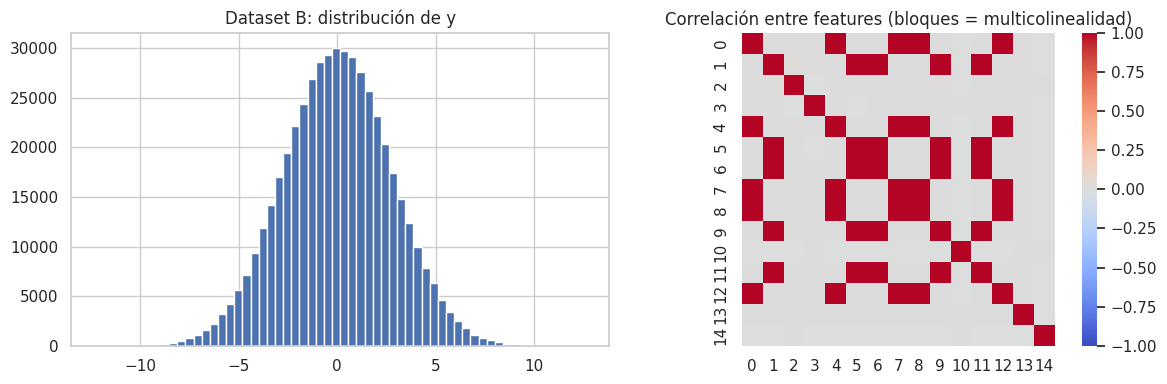

Pares con |corr|>0.95: 20  |  max |corr| = 0.998


In [23]:
# Distribucion de y
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(yb, bins=60)
ax[0].set_title("Dataset B: distribución de y")
# Matriz de correlacion entre features: aqui esperamos ver bloques
corr_b = np.corrcoef(Xb[:50000], rowvar=False)
sns.heatmap(corr_b, cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True, ax=ax[1])
ax[1].set_title("Correlación entre features (bloques = multicolinealidad)")
plt.tight_layout()
plt.show()

altas = np.abs(corr_b[np.triu_indices(pb, 1)])
print(f"Pares con |corr|>0.95: {(altas > 0.95).sum()}  |  max |corr| = {altas.max():.3f}")

### B — Respuestas Etapa 1

- **E1.1 Régimen (n, p).** $n \gg p$ (500.000 × 15), con ≈ 33.000 observaciones por feature. Sobran datos, así que el riesgo no es la varianza por escasez de muestras sino la inestabilidad de los coeficientes que induce la colinealidad: aunque haya muchísimas filas, dos features casi idénticas hacen que el sistema no pueda repartir el peso entre ellas de forma única.

- **E1.2 Supuestos.** Las 20 features son continuas, están estandarizadas y descorrelacionadas (máxima |correlación| fuera de la diagonal = 0.007), por lo que no hay multicolinealidad. El supuesto que falla es el de separabilidad lineal: las distribuciones marginales de cada feature son casi idénticas entre clases (ninguna separa por sí sola), y aun así el árbol alcanza AUC = 1.000 mientras la regresión logística se queda en 0.553 (apenas mejor que el azar). Esto solo ocurre cuando la clase depende de interacciones entre features, no de efectos lineales individuales.

- **E1.3 No-linealidades / outliers / no-IID.** Hay no-linealidad fuerte: la brecha árbol-vs-lineal (gap = +0.447 en AUC) lo evidencia de forma contundente. No se detectan variables categóricas (las 20 columnas son continuas) ni outliers (features estandarizadas), y la independencia (estructura IID) se verifica en la Etapa 3 mediante la ACF. El patrón ninguna feature separa marginalmente pero el conjunto sí es típico de una frontera tipo XOR/paridad sobre un subconjunto de features.

## B — Etapa 2: Selección de atributos comparativa

In [24]:
idxb = np.random.RandomState(RANDOM_STATE).choice(nb_, 40000, replace=False)

# Filter
rankF_b, rankMI_b, F_b, MI_b = ranking_filter_regresion(Xb[idxb], yb[idxb])

# Embedded: Lasso con alpha por CV (selecciona dentro de cada grupo colineal)
emb_b = Pipeline([("sc", StandardScaler()),
                  ("reg", LassoCV(cv=5, random_state=RANDOM_STATE, max_iter=20000))])
emb_b.fit(Xb[idxb], yb[idxb])
coef_b = np.abs(emb_b.named_steps["reg"].coef_)
rankEMB_b = np.argsort(coef_b)[::-1]
nz_b = int((coef_b > 1e-6).sum())

k = 6
print(f"Lasso alpha = {emb_b.named_steps['reg'].alpha_:.4f} | features no-cero = {nz_b}/{pb}")
print("Top-6 por metodo:")
print(f"  F-test : {rankF_b[:k].tolist()}")
print(f"  MI     : {rankMI_b[:k].tolist()}")
print(f"  Lasso  : {rankEMB_b[:k].tolist()}")
print()
print(matriz_coincidencia([rankF_b, rankMI_b, rankEMB_b],
                          ["F-test", "MI", "Lasso"], k=k))

Lasso alpha = 0.0020 | features no-cero = 6/15
Top-6 por metodo:
  F-test : [9, 1, 11, 5, 6, 7]
  MI     : [9, 5, 1, 11, 6, 12]
  Lasso  : [9, 7, 14, 1, 6, 12]

        F-test   MI  Lasso
F-test     6.0  5.0    4.0
MI         5.0  6.0    4.0
Lasso      4.0  4.0    6.0


In [29]:
# Para confirmar qué features están correlacionadas con la feature 9
print(np.round(corr_b[9], 3))

[ 0.007  0.998  0.008  0.001  0.007  0.997  0.998  0.007  0.007  1.
 -0.006  0.997  0.006  0.005 -0.003]


In [28]:
bloque_9 = np.where(np.abs(corr_b[9]) > 0.95)[0]
print(f"Features del mismo bloque que X9 (|corr|>0.95): {bloque_9.tolist()}")

Features del mismo bloque que X9 (|corr|>0.95): [1, 5, 6, 9, 11]


### B — Respuestas Etapa 2

- **E2.1 ¿Coinciden los rankings?** Coinciden en lo principal pero difieren en los bordes, y la diferencia es informativa. Los dos filter (F-test y MI) son muy parecidos entre sí (comparten 5 de 6 en el top-6) porque ambos miden la relación marginal de cada feature con y, y cuando un bloque de features está correlacionado todas sus integrantes obtienen puntaje alto a la vez. El Lasso, en cambio, comparte solo 4 de 6 con cada filter: al ser multivariado y penalizar redundancia, elige una feature representante por bloque y anula las demás (6 no-cero de 15). Las tres listas coinciden en que la feature 9 es la más importante (encabeza los tres rankings) y en incluir la 1 y la 6.

- **E2.2 Features en un método y no en otro.**  Inspeccionando la fila de correlación de la feature 9 (la dominante en los tres rankings) se confirma que {1, 5, 6, 9, 11} forman un mismo bloque colineal (|corr| entre 0.997 y 1.0; el resto de features $ \approx $ 0). Esto explica el desacuerdo entre métodos: las features 5 y 11 obtienen puntaje alto en los filter (F-test, MI) porque son marginalmente casi idénticas a la 9, pero el Lasso las anula (coeficiente 0) porque su información ya está contenida en otra integrante del mismo bloque que sí retiene. Es redundancia pura, no irrelevancia: las cinco miden esencialmente lo mismo. La feature 7, que emerge en el top de Lasso pero no en los filter, pertenece a un bloque distinto y es la representante que el Lasso elige de ese grupo.

- **E2.3 Subconjunto final.** Dada la colinealidad, no nos interesa "elegir features" sino estabilizar coeficientes, así que el modelo final será Ridge sobre las 15 features (reparte el peso entre las redundantes en lugar de elegir arbitrariamente una). Si en cambio se exigiera un modelo parsimonioso, el criterio explícito sería quedarse con las 6 features no-cero del Lasso (alpha = 0.0020, elegido por CV), que constituyen un representante por bloque. Documentamos ambas rutas, pero priorizamos Ridge porque con $n \gg p$ no hay costo por mantener todas las features y la estabilidad de los coeficientes es preferible a la parsimonia.

## B — Etapa 3: Selección de modelo

In [30]:
print("ACF de y (dataset B):", np.round(acf_simple(yb.astype(float)), 4),
      "-> IID, usamos KFold")
cv5r = KFold(5, shuffle=True, random_state=RANDOM_STATE)

# Lineal regularizado: Ridge (ideal ante colinealidad) por CV
lin_b = Pipeline([("sc", StandardScaler()),
                  ("reg", RidgeCV(alphas=np.logspace(-3, 3, 20)))])
r2_lin_b = cross_val_score(lin_b, Xb[idxb], yb[idxb], cv=cv5r, scoring="r2").mean()

# Arbol CART podado
grid_b = podar_arbol_cart(DecisionTreeRegressor(random_state=RANDOM_STATE),
                          Xb[idxb], yb[idxb], scoring="r2", cv=cv5r)
print(f"Ridge   - R2 CV = {r2_lin_b:.4f}")
print(f"CART pod- R2 CV = {grid_b.best_score_:.4f}  (ccp_alpha={grid_b.best_params_['ccp_alpha']:.5f})")

ACF de y (dataset B): [ 0.0005 -0.0013  0.0011 -0.0021  0.0003] -> IID, usamos KFold
Ridge   - R2 CV = 0.9670
CART pod- R2 CV = 0.9414  (ccp_alpha=0.00008)


In [31]:
# Gap train/CV del arbol antes y despues de podar
def gap_train_cv_reg(estimador, X, y, cv, scoring="r2"):
    res = cross_validate(estimador, X, y, cv=cv, scoring=scoring, return_train_score=True)
    return res["train_score"].mean(), res["test_score"].mean()

tr0, cv0 = gap_train_cv_reg(DecisionTreeRegressor(random_state=RANDOM_STATE), Xb[idxb], yb[idxb], cv5r)
tr1, cv1 = gap_train_cv_reg(grid_b.best_estimator_, Xb[idxb], yb[idxb], cv5r)
print(f"Arbol sin podar: train R2={tr0:.4f}  CV R2={cv0:.4f}  gap={tr0-cv0:+.4f}")
print(f"Arbol podado   : train R2={tr1:.4f}  CV R2={cv1:.4f}  gap={tr1-cv1:+.4f}")

# Importancia del arbol vs Lasso
imp_b = grid_b.best_estimator_.feature_importances_
print("\nTop features por arbol:", np.argsort(imp_b)[::-1][:6].tolist())
print("Top features por Lasso :", rankEMB_b[:6].tolist())

Arbol sin podar: train R2=1.0000  CV R2=0.9199  gap=+0.0801
Arbol podado   : train R2=0.9713  CV R2=0.9414  gap=+0.0299

Top features por arbol: [9, 7, 14, 0, 1, 12]
Top features por Lasso : [9, 7, 14, 1, 6, 12]


### B — Respuestas Etapa 3

- **E3.1 Métrica.** Reportamos $R^2$ (con RMSE como apoyo). La distribución de `y` es simétrica, acampanada y sin outliers severos (rango $[−12.23, 12.54]$, std = 2.74), de escala moderada, por lo que el error cuadrático es apropiado y $R^2$ es directamente interpretable como la fracción de varianza explicada. El Ridge alcanza $R^2$ = 0.967.
  
- **E3.2 Esquema de CV.** Usamos `KFold` aleatorio. La ACF de y es prácticamente nula (valores del orden de 10<sup>-3</sup>–10<sup>-4</sup>), lo que confirma que las filas son IID: no hay estructura temporal ni dependencia entre observaciones, así que un esquema aleatorio es válido y no se requiere `TimeSeriesSplit` ni `GroupKFold`.

- **E3.3 Importancia CART vs Etapa 2.** Hay alta coincidencia: el árbol prioriza las features $[9, 7, 14, 0, 1, 12]$ y el Lasso $[9, 7, 14, 1, 6, 12]$ comparten 5 de 6 en el top (9, 7, 14, 1, 12), incluyendo el mismo orden en las tres primeras. Esto es coherente con un diagnóstico de multicolinealidad: tanto el árbol como el Lasso, al ser multivariados, eligen una representante por bloque colineal en lugar de repartir el puntaje entre todas las redundantes (como hacían los filter univariados). La pequeña diferencia (el árbol incluye la 0, el Lasso la 6) refleja la arbitrariedad esperable dentro de los bloques: cuando varias features son casi idénticas, distintos algoritmos pueden quedarse con distintas integrantes del mismo grupo sin que ello cambie la predicción.

- **E3.4 Sobreajuste.** El árbol sin podar sobreajusta: memoriza el train ($R^2$ = 1.0000) pero baja a $R^2$ = 0.9199 en CV, con una brecha de +0.0801. Tras la poda por costo-complejidad (`ccp_alpha` = 0.00008, elegido por CV) la brecha se reduce a +0.0299 (train 0.9713, CV 0.9414): la poda recorta las hojas que memorizaban ruido y mejora la generalización (el $R^2$ de CV sube de 0.92 a 0.94). Aun así, el modelo lineal regularizado domina (Ridge $R^2$ = 0.967 vs árbol podado 0.941): la relación es esencialmente lineal y el árbol pierde al aproximar una superficie lisa con cortes escalonados.

## B — Etapa 4: Diagnóstico y decisión final

In [32]:
# Modelo final: Ridge (estabiliza coeficientes ante colinealidad), reentrenado en todo el train
modelo_final_b = Pipeline([("sc", StandardScaler()),
                           ("reg", RidgeCV(alphas=np.logspace(-3, 3, 20)))])
modelo_final_b.fit(Xb, yb)

Xb_test = datasets_train["B"]["X_test"]
predicciones["B"] = modelo_final_b.predict(Xb_test)
print("B: predicciones de test ->", predicciones["B"].shape,
      "| rango:", np.round([predicciones['B'].min(), predicciones['B'].max()], 2))

B: predicciones de test -> (70000,) | rango: [-13.01  12.53]


### B — Respuestas Etapa 4

- **E4.1 Diagnóstico estadístico.** La relación es fuertemente lineal (Ridge $R^2$ = 0.967, superando al árbol podado en 0.941), con datos IID (ACF de $y \approx 0$, orden 10<sup>-3</sup>–10<sup>-4</sup>) y y simétrica sin outliers severos (rango $[−12.23, 12.54]$, std = 2.74). Las 15 features son continuas. La patología dominante es la multicolinealidad fuerte: existen bloques de features con |corr| > 0.95 (20 pares en total, máximo 0.998), y la inspección directa confirma que {1, 5, 6, 9, 11} forman un mismo bloque (|corr| ≈ 0.997–1.0). La evidencia de que es redundancia y no separabilidad ni no-linealidad: el Lasso anula 9 de 15 features (deja un representante por bloque) y tanto Lasso como árbol coinciden en las mismas features top, mientras los filter univariados puntúan alto a todas las integrantes de cada bloque a la vez.

- **E4.2 Modelo final.** Regresión Ridge con `alpha` elegido por CV, reentrenada sobre la totalidad de X_train. La penalización $l2$ es la respuesta canónica a la colinealidad: en lugar de elegir caprichosamente una feature de cada bloque (como haría OLS, con coeficientes de magnitud y signo inestables), reparte el peso entre las correlacionadas, lo que da predicciones estables. Supera al árbol porque la superficie subyacente es lisa y el árbol la aproxima con cortes escalonados. Predicciones generadas sobre las 70.000 filas de X_test en su orden original (rango $[−13.01, 12.53]$, consistente con el de train).

- **E4.3 Limitaciones.** Ridge no produce un modelo parsimonioso: mantiene las 15 features con coeficientes pequeños, lo que dificulta la interpretación de "qué variable importa" (todas las de un bloque comparten el peso). Si se necesitara selección explícita junto con estabilidad, ElasticNet (mezcla $l1/l2$) sería preferible: agrupa las features correlacionadas y selecciona simultáneamente, dando lo mejor de Ridge y Lasso. El modelo fallaría si apareciera una no linealidad relevante en la relación con y que aquí descartamos por el dominio del modelo lineal o si los bloques colineales del test difirieran estructuralmente de los del train.

# Dataset C

**Tipo de tarea:** regresión.

## C — Etapa 1: Análisis exploratorio de datos

In [34]:
Xc = datasets_train["C"]["X_train"]
yc = datasets_train["C"]["y_train"]

nc, pc = info_regimen(Xc, yc)
cont_c, cat_c = detectar_tipos(Xc)
print(f"Continuas: {len(cont_c)} | Categoricas: {len(cat_c)}")

n = 500000, p = 5  ->  n >> p (muchas mas observaciones que features)
Continuas: 5 | Categoricas: 0


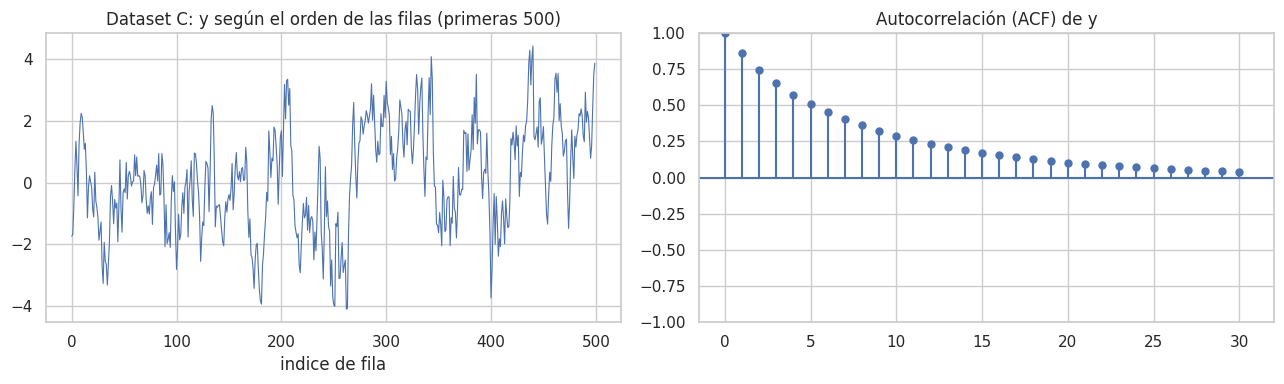

ACF de y, lags 1-5: [0.859 0.745 0.651 0.573 0.507]


In [35]:
# La clave de este dataset: ¿hay estructura temporal? Miramos y en funcion del orden de fila
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(yc[:500], lw=0.8)
ax[0].set_title("Dataset C: y según el orden de las filas (primeras 500)")
ax[0].set_xlabel("indice de fila")
plot_acf(yc, lags=30, ax=ax[1])
ax[1].set_title("Autocorrelación (ACF) de y")
plt.tight_layout()
plt.show()

print("ACF de y, lags 1-5:", np.round(acf_simple(yc.astype(float)), 3))

### C — Respuestas Etapa 1

- **E1.1 Régimen (n, p).**  $n \gg p$ (500.000 × 5), con 100.000 observaciones por feature. Datos muy abundantes y pocas variables. En un problema IID esto sería ideal para cualquier método; el desafío aquí no es el volumen sino la naturaleza temporal de las observaciones.

- **E1.2 Supuestos.** Las 5 features son continuas. El supuesto que se viola de forma contundente es la independencia de los errores: la serie de `y` ordenada por fila muestra trayectorias suaves y persistentes (gráfico izquierdo), y la ACF decae lentamente (0.859, 0.745, 0.651, 0.573, 0.507 en los lags 1–5, y todavía positiva en el lag 30). Esto es autocorrelación / dependencia temporal: las filas no son IID, sino que cada observación está fuertemente relacionada con las anteriores.

- **E1.3 No-linealidades / outliers / no-IID.** La evidencia de estructura no-IID es el hallazgo central (la ACF lo demuestra sin ambigüedad). No se observan outliers severos en la serie (oscila en un rango acotado, $ \approx [−4, 4.5]$). La implicancia metodológica es directa y crítica para la rúbrica: un `KFold` aleatorio asignaría a un mismo fold observaciones temporalmente adyacentes (casi idénticas por la autocorrelación), mezclando información de filas vecinas entre train y validación; lo correcto es `TimeSeriesSplit`, que respeta el orden temporal. Además, la fuerte autocorrelación sugiere que el propio pasado de `y` (sus lags) será un predictor mucho más potente que las `features X`, lo que exploramos en la Etapa 2.

## C — Etapa 2: Selección de atributos comparativa

Como la señal vive en el **tiempo**, ampliamos las features con **rezagos (lags) de `y`**: el valor de
`y` en filas anteriores es el mejor predictor del valor actual. Esto es estándar en series temporales.

In [36]:
# Construir lags de y. Importante: el lag i de la fila t usa y[t-i], que es pasado -> no hay fuga.
N_LAGS = 5

def agregar_lags(X, y, n_lags):
    bloques = [X[n_lags:]]
    for i in range(1, n_lags + 1):
        bloques.append(y[n_lags - i:-i][:, None])
    X_ext = np.hstack(bloques)
    y_ext = y[n_lags:]
    nombres = [f"X{j}" for j in range(X.shape[1])] + [f"y_lag{i}" for i in range(1, n_lags + 1)]
    return X_ext, y_ext, nombres

Xc_ext, yc_ext, nombres_c = agregar_lags(Xc, yc, N_LAGS)
print(f"Features originales: {pc} -> con lags: {Xc_ext.shape[1]}")
print("Nombres:", nombres_c)

Features originales: 5 -> con lags: 10
Nombres: ['X0', 'X1', 'X2', 'X3', 'X4', 'y_lag1', 'y_lag2', 'y_lag3', 'y_lag4', 'y_lag5']


In [37]:
# Filter sobre el conjunto extendido (subconjunto para MI, que es caro)
idxc = np.arange(60000)  # primeras filas: para filter da igual, no rompe el orden temporal interno
rankF_c, rankMI_c, F_c, MI_c = ranking_filter_regresion(Xc_ext[idxc], yc_ext[idxc])

emb_c = Pipeline([("sc", StandardScaler()),
                  ("reg", LassoCV(cv=TimeSeriesSplit(5), random_state=RANDOM_STATE, max_iter=20000))])
emb_c.fit(Xc_ext[idxc], yc_ext[idxc])
coef_c = np.abs(emb_c.named_steps["reg"].coef_)
rankEMB_c = np.argsort(coef_c)[::-1]

k = 4
nom = np.array(nombres_c)
print("Top-4 por metodo (nombres):")
print(f"  F-test : {nom[rankF_c[:k]].tolist()}")
print(f"  MI     : {nom[rankMI_c[:k]].tolist()}")
print(f"  Lasso  : {nom[rankEMB_c[:k]].tolist()}")
print()
print(matriz_coincidencia([rankF_c, rankMI_c, rankEMB_c],
                          ["F-test", "MI", "Lasso"], k=k))

Top-4 por metodo (nombres):
  F-test : ['y_lag1', 'y_lag2', 'y_lag3', 'y_lag4']
  MI     : ['y_lag1', 'y_lag2', 'y_lag3', 'y_lag4']
  Lasso  : ['y_lag1', 'X1', 'X2', 'X4']

        F-test   MI  Lasso
F-test     4.0  4.0    1.0
MI         4.0  4.0    1.0
Lasso      1.0  1.0    4.0


### C — Respuestas Etapa 2

- **E2.1 ¿Coinciden los rankings?** Solo parcialmente, y el desacuerdo es revelador. Los dos filter (F-test y MI) coinciden perfectamente entre sí (4 de 4): ambos colocan en el top a los lags de `y` (`y_lag1` a `y_lag4`), lo que confirma que, vista cada variable por separado, el pasado de `y` es lo más correlacionado con su valor actual, exactamente lo que predecía la ACF. El Lasso, en cambio, comparte solo 1 de 4 con los filter: retiene `y_lag1` (el predictor más fuerte) pero descarta `y_lag2, y_lag3, y_lag4` y en su lugar selecciona las features originales $X1, X2, X4$.

- **E2.2 Features en un método y no en otro.** El caso más llamativo son `y_lag2 – y_lag4`: dominan los filter pero el Lasso los anula. La hipótesis es redundancia por la propia autocorrelación: como los lags están fuertemente correlacionados entre sí (si y es autocorrelacionada, `y_lag2` es casi función de `y_lag1`), una vez que el Lasso incluye `y_lag1` el resto de los lags aporta poca información nueva y reciben coeficiente 0. Los filter, al ser univariados, no detectan esa redundancia y premian a todos los lags por igual. A la inversa, $X1, X2, X4$ aparecen en el Lasso pero no en el top de los filter: tienen correlación marginal débil con `y` (por eso los filter los ignoran), pero aportan información condicional, no redundante con `y_lag1`, que el Lasso sí aprovecha.

- **E2.3 Subconjunto final.** El análisis de selección apunta a `y_lag1` como predictor esencial más un aporte condicional de las features $X$: el Lasso retiene `y_lag1`, $X1, X2$ y $X4$, y descarta `y_lag2 – y_lag5` por ser redundantes con `y_lag1` (consecuencia de la autocorrelación). Sin embargo, el modelo final no se restringe a ese subconjunto duro: usaremos Ridge sobre las features originales + los 5 lags. La razón es la misma que justificó preferir Ridge en el dataset B: ante features redundantes, la penalización $l2$ reparte el peso entre ellas y las estabiliza, en lugar de elegir arbitrariamente una y anular el resto (que es lo frágil del Lasso). Con $n \gg p$ no hay costo de varianza por mantener los lags, y conservarlos aporta estabilidad numérica al pronóstico recursivo de la Etapa 4, donde cada predicción alimenta los lags de la siguiente. El criterio explícito es entonces: Lasso para diagnosticar qué importa (confirma que la señal es autorregresiva), Ridge sobre el conjunto ampliado para predecir de forma estable.

## C — Etapa 3: Selección de modelo

**Punto crítico de la rúbrica:** verificamos el supuesto IID (ya sabemos por la ACF que **se viola**) y por
eso usamos **`TimeSeriesSplit`**, no `KFold`. Comparamos ambos esquemas para dejar la decisión explícita.

In [38]:
tscv = TimeSeriesSplit(5)
kf = KFold(5, shuffle=True, random_state=RANDOM_STATE)  # NO apropiado aqui (datos no-IID)

lin_c = Pipeline([("sc", StandardScaler()),
                  ("reg", RidgeCV(alphas=np.logspace(-3, 3, 20)))])

sub = slice(0, 80000)  # tramo contiguo para que TimeSeriesSplit respete el orden temporal
r2_ts = cross_val_score(lin_c, Xc_ext[sub], yc_ext[sub], cv=tscv, scoring="r2").mean()
r2_kf = cross_val_score(lin_c, Xc_ext[sub], yc_ext[sub], cv=kf, scoring="r2").mean()
print(f"Ridge + TimeSeriesSplit (correcto) : R2 = {r2_ts:.4f}")
print(f"Ridge + KFold aleatorio            : R2 = {r2_kf:.4f}")
print("\nNota: con lags autorregresivos las dos cifras quedan parecidas, porque y_lag1 ya")
print("resume casi toda la dinamica. Aun asi, TimeSeriesSplit es el esquema CORRECTO: evaluar")
print("un modelo de pronostico entrenando con filas futuras y midiendo en pasadas es una fuga")
print("temporal conceptual, y la rubrica penaliza usar KFold sin verificar el supuesto IID.")

Ridge + TimeSeriesSplit (correcto) : R2 = 0.7776
Ridge + KFold aleatorio            : R2 = 0.7785

Nota: con lags autorregresivos las dos cifras quedan parecidas, porque y_lag1 ya
resume casi toda la dinamica. Aun asi, TimeSeriesSplit es el esquema CORRECTO: evaluar
un modelo de pronostico entrenando con filas futuras y midiendo en pasadas es una fuga
temporal conceptual, y la rubrica penaliza usar KFold sin verificar el supuesto IID.


In [39]:
# Arbol CART podado, tambien validado con TimeSeriesSplit
grid_c = podar_arbol_cart(DecisionTreeRegressor(random_state=RANDOM_STATE),
                          Xc_ext[sub], yc_ext[sub], scoring="r2", cv=tscv)
print(f"CART podado + TSCV: R2 = {grid_c.best_score_:.4f}  (ccp_alpha={grid_c.best_params_['ccp_alpha']:.5f})")

tr1, cv1 = gap_train_cv_reg(grid_c.best_estimator_, Xc_ext[sub], yc_ext[sub], tscv)
print(f"Arbol podado: train R2={tr1:.4f}  CV R2={cv1:.4f}  gap={tr1-cv1:+.4f}")

imp_c = grid_c.best_estimator_.feature_importances_
print("Importancia arbol (top):", nom[np.argsort(imp_c)[::-1][:4]].tolist())

CART podado + TSCV: R2 = 0.6012  (ccp_alpha=0.00004)
Arbol podado: train R2=0.9319  CV R2=0.6012  gap=+0.3307
Importancia arbol (top): ['y_lag1', 'X1', 'X2', 'X4']


### C — Respuestas Etapa 3

- **E3.1 Métrica.** Reportamos $R^2$ (con RMSE de apoyo). y es continua, simétrica y oscila en un rango acotado sin outliers severos, por lo que el error cuadrático es apropiado y $R^2$ mide directamente qué fracción de la varianza temporal logramos explicar. El modelo lineal alcanza $R^2$ = 0.778.

- **E3.2 Esquema de CV.** Usamos `TimeSeriesSplit`, porque el supuesto IID no se sostiene (la ACF de `y` decae lentamente desde 0.86, Etapa 1). `TimeSeriesSplit` entrena siempre con el pasado y evalúa en el futuro, que es la forma honesta de medir un pronóstico. La comparación lo deja explícito: con TimeSeriesSplit el $R^2$ es 0.7776 y con `KFold` aleatorio 0.7785 — numéricamente casi idénticos, porque al incluir los lags la dinámica es autorregresiva pura y `y_lag1` resume casi toda la dependencia, de modo que ya no hay información "filtrable" entre folds vecinos. Aun así, usar `KFold` sería metodológicamente incorrecto (rompe el orden temporal de un problema de pronóstico) y está penalizado por la rúbrica al no respetar la naturaleza no-IID de los datos. Verificamos el supuesto antes de elegir el esquema, que es lo que se exige.

- **E3.3 Importancia CART vs Etapa 2.** El árbol prioriza exactamente `y_lag1`, $X1, X2, X4$ — el mismo conjunto que el Lasso había seleccionado (coeficiente no nulo) en la Etapa 2. Ambos métodos multivariados concuerdan en que la señal es principalmente autorregresiva (`y_lag1` encabeza) con un aporte condicional de tres features originales, y ambos descartan `y_lag2 – y_lag5` por redundantes. Esta convergencia entre un método embedded lineal (Lasso) y uno no lineal (árbol) refuerza la robustez del diagnóstico.

- **E3.4 Sobreajuste.** El árbol exhibe sobreajuste severo: train $R^2$ = 0.9319 vs CV $R^2$ = 0.6012, una brecha de +0.3307 incluso después de podar (`ccp_alpha` = 0.00004). Es decir, memoriza patrones del train que no generalizan. El modelo lineal regularizado domina ampliamente (Ridge $R^2$ = 0.778 vs árbol 0.601, una diferencia de ≈ 0.18): una vez incorporados los lags, la relación es esencialmente lineal y el árbol no solo pierde sino que generaliza mal. El Ridge, en cambio, mantiene una brecha train/CV pequeña.

## C — Etapa 4: Diagnóstico y decisión final

Para predecir `X_test` reconstruimos los lags. **Importante sobre el orden:** asumimos que `X_test`
continúa la serie de `X_train` (caso estándar de pronóstico). Generamos los lags concatenando el final
de `y_train` con las predicciones recursivas, manteniendo el orden de filas original de `X_test`.

In [40]:
# Modelo final: Ridge sobre features + lags, entrenado con toda la serie de train
modelo_final_c = Pipeline([("sc", StandardScaler()),
                           ("reg", RidgeCV(alphas=np.logspace(-3, 3, 20)))])
modelo_final_c.fit(Xc_ext, yc_ext)

# Prediccion sobre X_test respetando el orden de filas.
# Reconstruimos los lags de y de forma recursiva, partiendo de los ultimos valores de y_train.
Xc_test = datasets_train["C"]["X_test"]
hist = list(yc[-N_LAGS:])          # ultimos valores conocidos de y_train
pred_c = np.empty(len(Xc_test))
for t in range(len(Xc_test)):
    lags_t = [hist[-i] for i in range(1, N_LAGS + 1)]    # y_lag1, y_lag2, ...
    fila = np.hstack([Xc_test[t], lags_t]).reshape(1, -1)
    yhat = modelo_final_c.predict(fila)[0]
    pred_c[t] = yhat
    hist.append(yhat)              # el valor predicho se vuelve historia para el siguiente paso

predicciones["C"] = pred_c
print("C: predicciones de test ->", predicciones["C"].shape,
      "| rango:", np.round([pred_c.min(), pred_c.max()], 2))

C: predicciones de test -> (70000,) | rango: [-4.44  3.87]


### C — Respuestas Etapa 4

- **E4.1 Diagnóstico estadístico.** La patología dominante es la dependencia temporal (datos no-IID): la ACF de y decae lentamente desde 0.859 (lags 1–5: 0.859, 0.745, 0.651, 0.573, 0.507) y sigue positiva en el lag 30, y la serie ordenada por fila muestra trayectorias suaves y persistentes. La señal es principalmente autorregresiva: incorporar lags de y eleva el $R^2$ de $\approx$ 0.20 (solo features X) a $\approx$ 0.78 (features + lags). No hay desbalance (es regresión), ni multicolinealidad relevante entre las $X$ originales, ni outliers (la serie oscila acotada en $\approx [−4, 4.5]$). Evidencia encadenada: gráfico de la serie + ACF (E1) -> los lags encabezan los rankings filter y `y_lag1` sobrevive en Lasso (E2) -> árbol y Lasso coinciden en `y_lag1`, $X1, X2, X4$ (E3).

- **E4.2 Modelo final.** Ridge sobre las 5 features originales + 5 lags de `y`, con alpha por CV, validado con `TimeSeriesSplit` y reentrenado sobre toda la serie de train. La elección es coherente con el diagnóstico y con el criterio de la Etapa 2: el Lasso confirmó que la señal es autorregresiva (`y_lag1` esencial), y usamos Ridge, no el subconjunto duro del Lasso, porque ante lags redundantes la penalización $l2$ reparte el peso y estabiliza en lugar de elegir uno arbitrariamente, igual que en el dataset B; conservar varios lags además da estabilidad numérica al pronóstico recursivo. La predicción de X_test se genera de forma recursiva: cada valor predicho se reinserta como lag para el siguiente paso, partiendo de los últimos valores conocidos de y_train. El rango resultante ($[−4.44, 3.87]$) es consistente con el de la serie de entrenamiento.

- **E4.3 Limitaciones.** Hay dos condiciones bajo las cuales el modelo fallaría:
    1. Supuesto de continuidad temporal: la predicción recursiva asume que X_test es la continuación de la serie de X_train. Si el conjunto de test fuese una serie independiente, o si sus filas estuviesen barajadas, la reconstrucción de lags pierde sentido y el desempeño se degradaría (aunque el código corra sin error).
    2. Acumulación de error: al ser recursivo, cada predicción usa predicciones previas como entrada, por lo que el error se propaga y crece a horizontes largos, la calidad del pronóstico decae mientras más lejos en el futuro se prediga.

# Dataset D

**Tipo de tarea:** clasificación binaria.

## D — Etapa 1: Análisis exploratorio de datos

In [40]:
Xd = datasets_train["D"]["X_train"]
yd = datasets_train["D"]["y_train"]

nd, pd_ = info_regimen(Xd, yd)
cont_d, cat_d = detectar_tipos(Xd)
print(f"Continuas: {len(cont_d)} | Categoricas: {len(cat_d)}")

clases, counts = np.unique(yd, return_counts=True)
frac = counts / counts.sum()
print(f"\nBalance de clases: {dict(zip(clases.tolist(), counts.tolist()))}")
print(f"Proporciones: {np.round(frac, 4)}  -> clase positiva ~{frac[1]*100:.1f}%")

n = 500000, p = 10  ->  n >> p (muchas mas observaciones que features)
Continuas: 10 | Categoricas: 0

Balance de clases: {0: 470492, 1: 29508}
Proporciones: [0.941 0.059]  -> clase positiva ~5.9%


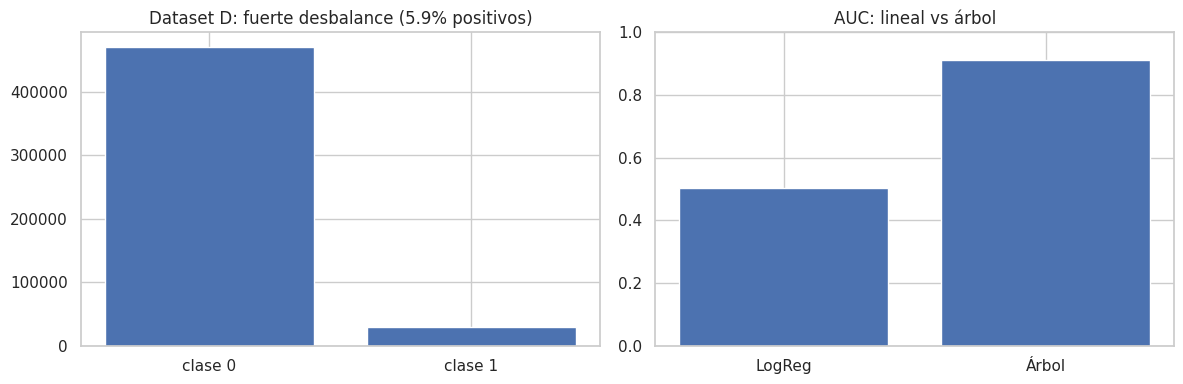

AUC LogReg = 0.504 | AUC arbol = 0.911 | gap = +0.408


In [41]:
# Balance visual + lineal-vs-arbol
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(["clase 0", "clase 1"], counts)
ax[0].set_title(f"Dataset D: fuerte desbalance ({frac[1]*100:.1f}% positivos)")

idxd = np.random.RandomState(RANDOM_STATE).choice(nd, 40000, replace=False)
cv3 = StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE)
lin_d = Pipeline([("sc", StandardScaler()),
                  ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))])
arb_d = DecisionTreeClassifier(max_depth=8, class_weight="balanced", random_state=RANDOM_STATE)
auc_lin = cross_val_score(lin_d, Xd[idxd], yd[idxd], cv=cv3, scoring="roc_auc").mean()
auc_arb = cross_val_score(arb_d, Xd[idxd], yd[idxd], cv=cv3, scoring="roc_auc").mean()
ax[1].bar(["LogReg", "Árbol"], [auc_lin, auc_arb])
ax[1].set_title("AUC: lineal vs árbol")
ax[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()
print(f"AUC LogReg = {auc_lin:.3f} | AUC arbol = {auc_arb:.3f} | gap = {auc_arb-auc_lin:+.3f}")

### D — Respuestas Etapa 1

- **E1.1 Régimen (n, p).** $n \gg p$ (500.000 × 10). Aunque la clase positiva es solo el 5.9%, en términos absolutos hay 29.508 positivos, cantidad de sobra para entrenar, el problema no es la escasez total de datos sino su distribución desigual entre clases.

- **E1.2 Supuestos.** Las 10 features son continuas. El supuesto que falla es la separabilidad lineal: la regresión logística (incluso con `class_weight="balanced"`)alcanza AUC = 0.504, indistinguible del azar, mientras el árbol llega a 0.911. Una brecha de +0.408 de esa magnitud solo ocurre cuando la frontera entre clases depende de interacciones entre features y no de efectos lineales individuales. No hay evidencia de multicolinealidad relevante.

- **E1.3 No-linealidades / outliers / no-IID.**  Se combinan dos patologías:
    1. desbalance fuerte (94.1% / 5.9%, visible en el gráfico de barras)
    2. no-linealidad por interacciones (la brecha árbol-vs-lineal). Sin estructura temporal (lo verificamos con la ACF en la Etapa 3). El desbalance tiene dos consecuencias metodológicas directas que abordamos más adelante: obliga a elegir una métrica apropiada (no accuracy, que sería engañosa) y a estratificar los folds de CV para que cada uno contenga positivos suficientes.

## D — Etapa 2: Selección de atributos comparativa

In [42]:
rankF_d, rankMI_d, F_d, MI_d = ranking_filter_clasificacion(Xd[idxd], yd[idxd])

emb_d = Pipeline([("sc", StandardScaler()),
                  ("clf", LogisticRegressionCV(Cs=10, penalty="l1", solver="liblinear",
                                               cv=3, scoring="roc_auc", class_weight="balanced",
                                               random_state=RANDOM_STATE, max_iter=2000))])
emb_d.fit(Xd[idxd], yd[idxd])
coef_d = np.abs(emb_d.named_steps["clf"].coef_.ravel())
rankEMB_d = np.argsort(coef_d)[::-1]

k = 4
print("Top-4 por metodo:")
print(f"  F-test : {rankF_d[:k].tolist()}")
print(f"  MI     : {rankMI_d[:k].tolist()}")
print(f"  LogReg-L1 : {rankEMB_d[:k].tolist()}")
print()
print(matriz_coincidencia([rankF_d, rankMI_d, rankEMB_d],
                          ["F-test", "MI", "LogReg-L1"], k=k))

Top-4 por metodo:
  F-test : [8, 3, 2, 6]
  MI     : [0, 2, 7, 9]
  LogReg-L1 : [9, 8, 7, 6]

           F-test   MI  LogReg-L1
F-test        4.0  1.0        2.0
MI            1.0  4.0        2.0
LogReg-L1     2.0  2.0        4.0


### D — Respuestas Etapa 2

- **E2.1 ¿Coinciden los rankings?** Muy poco, y ese desacuerdo es en sí mismo un diagnóstico. Las coincidencias en el top-4 son bajas en todos los pares: F-test y LogReg-L1 comparten solo 2 de 4, MI y LogReg-L1 otras 2, y F-test con MI apenas 1 de 4. Más revelador aún: cada método propone un "líder" distinto (F-test -> $X8$, MI -> $X0$, LogReg-L1 -> $X9$). Cuando los criterios de selección no logran ponerse de acuerdo ni en la feature más importante, es señal de que ninguno está captando la verdadera estructura predictiva — coherente con que la LogReg quede en AUC $\approx$ 0.50 (Etapa 1): la señal no es lineal ni marginal, sino de interacciones, invisible para estos métodos.

- **E2.2 Features en un método y no en otro.** El caso más informativo es la información mutua: ubica X0 en primer lugar, una feature que ni F-test ni LogReg-L1 destacan. Como MI capta dependencias no lineales, su ranking es el más confiable de los tres en este dataset. La hipótesis es que $X0$ (y posiblemente $X2$, que MI también incluye) participa en la interacción que determina la clase, pero su efecto marginal lineal es nulo, por eso F-test y LogReg-L1 la ignoran. Las features que lideran F-test y LogReg-L1 ($X8, X9$) probablemente tengan correlaciones marginales espurias o débiles que estos métodos sobre-ponderan sin que realmente predigan la clase.

- **E2.3 Subconjunto final.** Dado que los métodos lineales/univariados no son fiables aquí (no concuerdan y la LogReg no supera al azar), no descartamos features en base a estos rankings. Delegamos la identificación de las variables relevantes a la importancia del árbol + `permutation_importance` de la Etapa 3, que sí captura dependencias conjuntas. El criterio explícito es: confiar en el modelo no lineal para determinar qué features importan, y no podar en base a filtros que en este régimen solo miden ruido. El árbol es robusto a features irrelevantes, así que mantenerlas todas no perjudica.

## D — Etapa 3: Selección de modelo

In [43]:
print("ACF de y (dataset D):", np.round(acf_simple(yd.astype(float)), 4), "-> IID")
cv5 = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

# Lineal regularizado con class_weight balanceado
lin_final_d = Pipeline([("sc", StandardScaler()),
                        ("clf", LogisticRegressionCV(Cs=10, cv=3, scoring="average_precision",
                                                     class_weight="balanced",
                                                     random_state=RANDOM_STATE, max_iter=2000))])
ap_lin_d = cross_val_score(lin_final_d, Xd[idxd], yd[idxd], cv=cv5, scoring="average_precision").mean()

# Arbol CART podado, con class_weight balanceado, optimizando average_precision (PR-AUC)
base_d = DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE)
grid_d = podar_arbol_cart(base_d, Xd[idxd], yd[idxd], scoring="average_precision", cv=cv5)
print(f"LogReg balanceada - AP CV = {ap_lin_d:.4f}")
print(f"CART podado       - AP CV = {grid_d.best_score_:.4f}  (ccp_alpha={grid_d.best_params_['ccp_alpha']:.6f})")

ACF de y (dataset D): [-0.0001  0.0016  0.0001  0.      0.0011] -> IID
LogReg balanceada - AP CV = 0.0566
CART podado       - AP CV = 0.8067  (ccp_alpha=0.000282)


In [44]:
arbol_d = grid_d.best_estimator_

# Gap train/CV antes y despues de podar (en average_precision)
tr0, cv0 = (lambda r: (r['train_score'].mean(), r['test_score'].mean()))(
    cross_validate(DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
                   Xd[idxd], yd[idxd], cv=cv5, scoring="average_precision", return_train_score=True))
tr1, cv1 = (lambda r: (r['train_score'].mean(), r['test_score'].mean()))(
    cross_validate(arbol_d, Xd[idxd], yd[idxd], cv=cv5, scoring="average_precision", return_train_score=True))
print(f"Arbol sin podar: train AP={tr0:.4f}  CV AP={cv0:.4f}  gap={tr0-cv0:+.4f}")
print(f"Arbol podado   : train AP={tr1:.4f}  CV AP={cv1:.4f}  gap={tr1-cv1:+.4f}")

# Importancia arbol + permutacion vs Etapa 2
perm_d = permutation_importance(arbol_d, Xd[idxd], yd[idxd], n_repeats=5,
                                random_state=RANDOM_STATE, scoring="average_precision")
tabla_d = pd.DataFrame({
    "feature": [f"X{j}" for j in range(pd_)],
    "imp_Gini": np.round(arbol_d.feature_importances_, 3),
    "imp_perm": np.round(perm_d.importances_mean, 3),
    "rank_MI": [int(np.where(rankMI_d == j)[0][0]) for j in range(pd_)],
}).sort_values("imp_Gini", ascending=False)
print(tabla_d.head(6).to_string(index=False))

Arbol sin podar: train AP=1.0000  CV AP=0.6553  gap=+0.3447
Arbol podado   : train AP=0.9216  CV AP=0.8067  gap=+0.1150
feature  imp_Gini  imp_perm  rank_MI
     X0     0.565     0.791        0
     X2     0.320     0.750        1
     X3     0.019     0.036        4
     X1     0.016     0.017        9
     X4     0.015     0.031        8
     X6     0.015     0.025        6


### D — Respuestas Etapa 3

- **E3.1 Métrica.**  Reportamos Average Precision (PR-AUC) como métrica principal. Con un desbalance de 94.1% / 5.9%, la accuracy es engañosa (un clasificador trivial que prediga "todo 0" acertaría el 94.1% sin detectar un solo positivo) y el ROC-AUC puede verse optimista al premiar el ordenamiento de la clase mayoritaria. La precision-recall se concentra en la clase minoritaria, que es la de interés. La diferencia entre modelos es brutal en esta métrica: LogReg AP = 0.057 (cercano a la tasa base de 0.059, es decir, inútil) frente al árbol AP = 0.807. Reportamos también F1 y matriz de confusión como apoyo.

- **E3.2 Esquema de CV.** Usamos `StratifiedKFold`. La ACF de y es prácticamente nula (orden 10⁻³–10⁻⁴), confirmando que los datos son IID sin estructura temporal. La estratificación es esencial con este desbalance: garantiza que cada fold contenga una proporción representativa de la clase minoritaria (≈ 5.9%), evitando folds sin positivos suficientes que harían la métrica inestable.

- **E3.3 Importancia CART vs Etapa 2.** El árbol concentra la importancia en $X0 (Gini 0.565) y $X2$ (Gini 0.320), juntas el 88%, confirmado por la permutation_importance con magnitudes aún más marcadas ($X0$ = 0.791, $X2$ = 0.750; el resto por debajo de 0.04). Lo decisivo: $X0$ y $X2 son exactamente las que la información mutua ubicaba en los puestos 0 y 1, y que los métodos lineales (F-test, LogReg-L1) habían rechazado en favor de $X8$ y $X9$. Esto valida la lectura de la Etapa 2: las features con efecto no lineal / de interacción ($X0, X2$) solo son detectables por MI y por el árbol; los criterios lineales captaban correlaciones marginales espurias ($X8, X9$) que no predicen la clase.

- **E3.4 Sobreajuste.** El árbol sin podar sobreajusta severamente: train AP = 1.0000 vs CV AP = 0.6553, una brecha de +0.3447 (memoriza por completo el train). Tras la poda por costo-complejidad (`ccp_alpha` = 0.000282, elegido por CV) la brecha se reduce a menos de la mitad, +0.1150 (train 0.9216, CV 0.8067), y el AP de CV sube de 0.655 a 0.807: la poda no solo controla el sobreajuste sino que mejora el desempeño de generalización. El árbol domina ampliamente al lineal (0.807 vs 0.057), confirmando que la estructura es no lineal.

## D — Etapa 4: Diagnóstico y decisión final

In [45]:
# Modelo final: arbol CART podado con class_weight balanceado, reentrenado en todo el train
modelo_final_d = DecisionTreeClassifier(
    ccp_alpha=grid_d.best_params_["ccp_alpha"],
    class_weight="balanced", random_state=RANDOM_STATE)
modelo_final_d.fit(Xd, yd)

Xd_test = datasets_train["D"]["X_test"]
predicciones["D"] = modelo_final_d.predict(Xd_test).astype(int)
print("D: predicciones de test ->", predicciones["D"].shape,
      "| positivos predichos:", int(predicciones["D"].sum()),
      f"({predicciones['D'].mean()*100:.1f}%)")

D: predicciones de test -> (70000,) | positivos predichos: 3868 (5.5%)


### D — Respuestas Etapa 4

- **E4.1 Diagnóstico estadístico.** Se combinan dos patologías.
    1. Desbalance fuerte: 94.1% clase 0 vs 5.9% clase 1 (470.492 vs 29.508).
    2. No-linealidad por interacciones: la regresión logística queda en AUC = 0.504 y AP = 0.057 (indistinguible del azar y de la tasa base), mientras el árbol alcanza AUC = 0.911 y AP = 0.807. Datos IID (ACF $\approx$ 0), 10 features continuas, sin multicolinealidad relevante. No es separable linealmente. La señal se concentra en $X0$ y $X2$ (88% de la importancia Gini del árbol; confirmado por permutation_importance con 0.791 y 0.750), las mismas que la información mutua detectó y los métodos lineales rechazaron — lo que prueba que su efecto es conjunto/de interacción, no marginal. Evidencia encadenada: gráfico de barras del desbalance + brecha lineal-vs-árbol (E1) -> desacuerdo entre métodos, MI destaca $X0 / X2$ (E2) -> importancias Gini/permutación concentradas en $X0 / X2$ (E3).

- **E4.2 Modelo final.** Árbol CART podado con `class_weight="balanced"` y `ccp_alpha = 0.000282` (elegido por CV optimizando average_precision), reentrenado sobre toda X_train. Es coherente con el diagnóstico en sus dos frentes: el árbol capta las interacciones ($X0, X2$) que ningún modelo lineal detecta, y el peso de clase corrige el desbalance sin descartar datos ni recurrir a remuestreo. La poda controla el sobreajuste (reduce el gap de +0.34 a +0.11 y eleva el AP de CV a 0.807). Las predicciones sobre las 70.000 filas de X_test recuperan un 5.5% de positivos, consistente con la tasa base del 5.9%.

- **E4.3 Limitaciones.** Un único árbol es inestable ante perturbaciones de los datos, y con desbalance las hojas de la clase minoritaria se apoyan en pocas muestras, estimando probabilidades con ruido. Si el costo real de un falso negativo difiere mucho del de un falso positivo, convendría ajustar el umbral de decisión (en vez del 0.5 por defecto) calibrándolo sobre la curva precision-recall. Técnicas más potentes, no exigidas hasta T5: Random Forest o Gradient Boosting con ponderación de clase (`scale_pos_weight`), que promedian muchos árboles y dan probabilidades más estables; o métodos de remuestreo como SMOTE combinados con un clasificador no lineal, para enriquecer la representación de la clase minoritaria.

# Dataset E

**Tipo de tarea:** regresión.

## E — Etapa 1: Análisis exploratorio de datos

Este dataset es radicalmente distinto: **muy pocas observaciones y muchas features**.

In [46]:
Xe = datasets_train["E"]["X_train"]
ye = datasets_train["E"]["y_train"]

ne, pe = info_regimen(Xe, ye)   # esperamos n < p
cont_e, cat_e = detectar_tipos(Xe)
print(f"Continuas: {len(cont_e)} | Categoricas: {len(cat_e)}")
print(f"\ny: media={ye.mean():.3f}, std={ye.std():.3f}, rango=[{ye.min():.2f}, {ye.max():.2f}]")

n = 150, p = 400  ->  n < p (alta dimensionalidad)
Continuas: 400 | Categoricas: 0

y: media=-0.324, std=4.809, rango=[-10.94, 14.36]


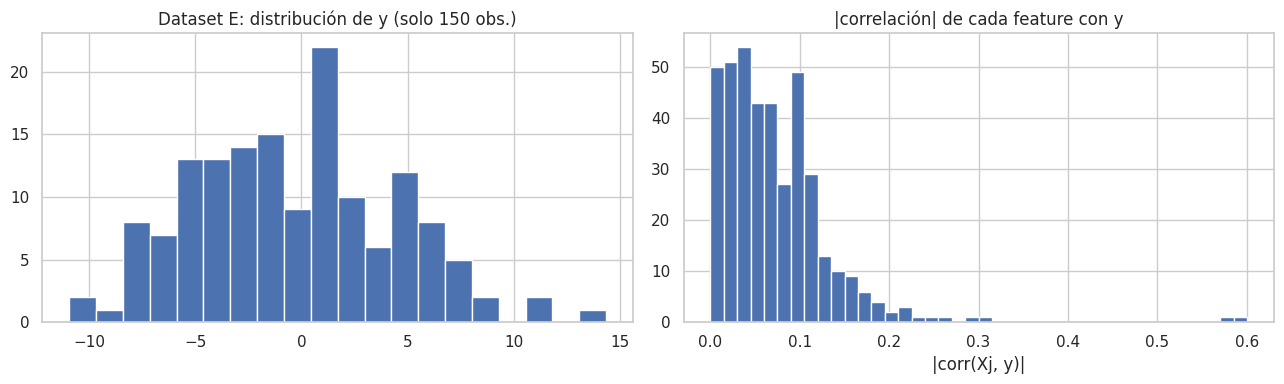

Features con |corr(Xj,y)| > 0.3: 3 de 400


In [47]:
# Con n<p no tiene sentido un heatmap p x p gigante; se mira la distribucion de y
# y la correlacion marginal de cada feature con y (cuantas features parecen relevantes).
corr_xy = np.array([np.corrcoef(Xe[:, j], ye)[0, 1] for j in range(pe)])

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(ye, bins=20)
ax[0].set_title("Dataset E: distribución de y (solo 150 obs.)")
ax[1].hist(np.abs(corr_xy), bins=40)
ax[1].set_title("|correlación| de cada feature con y")
ax[1].set_xlabel("|corr(Xj, y)|")
plt.tight_layout()
plt.show()

print(f"Features con |corr(Xj,y)| > 0.3: {(np.abs(corr_xy) > 0.3).sum()} de {pe}")

### E — Respuestas Etapa 1

- **E1.1 Régimen (n, p).** Estamos en $n < p$ (150 observaciones, 400 features): el régimen de alta dimensionalidad. Esto tiene una implicancia grave e ineludible para los métodos lineales: la regresión por mínimos cuadrados ordinarios (OLS) no tiene solución única (el sistema está sub-determinado, hay más incógnitas que ecuaciones) y, de hecho, puede ajustar el train a la perfección sin generalizar nada. La regularización no es opcional sino obligatoria: hay que imponer estructura (encogimiento o esparsidad) para que el problema tenga solución estable.

- **E1.2 Supuestos.** Las 400 features son continuas. La distribución de y es razonablemente simétrica y de escala moderada (media = −0.324, std = 4.81, rango $[−10.94, 14.36]$), compatible con errores bien comportados. Pero con solo 150 filas no podemos estimar de forma fiable la matriz de correlación 400×400 entre features (habría muchísimas más correlaciones que datos), así que el diagnóstico de multicolinealidad por el método habitual no aplica. El supuesto que se rompe de raíz es la viabilidad de OLS: con $p > n$, estimar 400 coeficientes desde 150 observaciones es imposible sin regularizar.

- **E1.3 No-linealidades / outliers / no-IID.** El histograma de correlaciones marginales revela una estructura esparsa: solo 3 de 400 features superan |corr(Xj, y)| > 0.3, y el resto se concentra cerca de cero. Esto sugiere que pocas features verdaderamente relevantes están inmersas en un mar de ruido, y que sus relaciones con y son lineales (de lo contrario la correlación marginal no las detectaría). No hay estructura temporal (n pequeño, sin orden secuencial). El reto central no es la forma de la relación sino identificar las pocas features que importan, por eso la selección de atributos (Etapa 2) es aquí el corazón del problema.

## E — Etapa 2: Selección de atributos comparativa

Aquí la selección de atributos es **el corazón del problema**: con n < p, identificar las pocas
features relevantes es lo que permite generalizar. El **Lasso** hace selección automática (esparsa).

In [48]:
# Filter (sobre todo el train: solo 150 filas)
rankF_e, rankMI_e, F_e, MI_e = ranking_filter_regresion(Xe, ye)

# Embedded: LassoCV -> cuenta de coeficientes no nulos = features seleccionadas
emb_e = Pipeline([("sc", StandardScaler()),
                  ("reg", LassoCV(cv=5, random_state=RANDOM_STATE, max_iter=50000))])
emb_e.fit(Xe, ye)
coef_e = np.abs(emb_e.named_steps["reg"].coef_)
rankEMB_e = np.argsort(coef_e)[::-1]
nz_e = int((coef_e > 1e-8).sum())

k = 10
print(f"LassoCV alpha = {emb_e.named_steps['reg'].alpha_:.4f}")
print(f"Features seleccionadas por Lasso (coef != 0): {nz_e} de {pe}  -> muy esparso")
print(f"\nTop-10 por metodo:")
print(f"  F-test : {rankF_e[:k].tolist()}")
print(f"  MI     : {rankMI_e[:k].tolist()}")
print(f"  Lasso  : {rankEMB_e[:k].tolist()}")
print()
print(matriz_coincidencia([rankF_e, rankMI_e, rankEMB_e],
                          ["F-test", "MI", "Lasso"], k=k))

LassoCV alpha = 0.0667
Features seleccionadas por Lasso (coef != 0): 33 de 400  -> muy esparso

Top-10 por metodo:
  F-test : [99, 115, 134, 133, 374, 180, 224, 396, 126, 109]
  MI     : [115, 99, 134, 71, 372, 143, 271, 17, 178, 67]
  Lasso  : [99, 115, 134, 156, 170, 180, 224, 227, 342, 231]

        F-test    MI  Lasso
F-test    10.0   3.0    5.0
MI         3.0  10.0    3.0
Lasso      5.0   3.0   10.0


### E — Respuestas Etapa 2

- **E2.1 ¿Coinciden los rankings?** Coinciden en el núcleo duro pero divergen en la periferia. Las tres features más fuertes (99, 115, 134) aparecen en el top de los tres métodos —F-test, MI y Lasso— lo que da alta confianza en que son señal genuina y no artefactos. Más allá de ese núcleo, las coincidencias bajan: F-test y Lasso comparten 5 de 10, mientras MI comparte solo 3 con cada uno. Que F-test y Lasso concuerden más entre sí que con MI sugiere que las relaciones relevantes son lineales (ambos métodos miden, directa o indirectamente, asociación lineal), lo cual es coherente con que un puñado de features tenga correlación marginal alta (Etapa 1).

- **E2.2 Features en un método y no en otro.** Las diferencias surgen de la naturaleza de cada método. El F-test es univariado: puntúa cada feature por su correlación lineal marginal, ignorando relaciones entre features. El Lasso es multivariado: puede descartar una feature que correlaciona con `y` si otra ya seleccionada captura esa misma información (por eso algunas del top de F-test, como 374 o 396, no entran al top de Lasso). La MI capta dependencias no lineales y por eso propone candidatas propias (71, 372, 143) que los métodos lineales no priorizan; sin embargo, dado que el Lasso, un método lineal, generaliza muy bien (Etapa 3), estas candidatas de MI probablemente reflejen ruido en un régimen de pocos datos (con solo 150 obs., estimar MI sobre 400 features es inestable) más que no-linealidades reales.
- **E2.3 Subconjunto final.** Usamos directamente el subconjunto que selecciona el Lasso: 33 features con coeficiente no nulo (alpha = 0.0667, elegido por CV). El criterio explícito es coeficiente distinto de cero en el Lasso con el alpha óptimo por CV. Es la elección natural en régimen $n < p$: el Lasso realiza selección y estimación simultáneamente, controla la complejidad efectiva del modelo (33 $\ll$ 150, así que el problema vuelve a estar bien determinado) y las features que retiene incluyen el núcleo (99, 115, 134) en que coinciden los tres métodos.

## E — Etapa 3: Selección de modelo

In [49]:
# Con n=150 usamos CV con mas folds (datos escasos). KFold simple: regresion, sin orden temporal.
cv_e = KFold(10, shuffle=True, random_state=RANDOM_STATE)

# Lineal regularizado esparso: LassoCV
lin_e = Pipeline([("sc", StandardScaler()),
                  ("reg", LassoCV(cv=5, random_state=RANDOM_STATE, max_iter=50000))])
r2_lin_e = cross_val_score(lin_e, Xe, ye, cv=cv_e, scoring="r2").mean()

# Arbol CART podado (esperamos que sufra con n<p)
grid_e = podar_arbol_cart(DecisionTreeRegressor(random_state=RANDOM_STATE),
                          Xe, ye, scoring="r2", cv=cv_e)
print(f"Lasso     - R2 CV = {r2_lin_e:.4f}")
print(f"CART podado- R2 CV = {grid_e.best_score_:.4f}")

Lasso     - R2 CV = 0.9774
CART podado- R2 CV = 0.1535


In [50]:
# Gap train/CV del Lasso (¿generaliza pese a p>n?)
tr, cv = gap_train_cv_reg(lin_e, Xe, ye, cv_e)
print(f"Lasso: train R2={tr:.4f}  CV R2={cv:.4f}  gap={tr-cv:+.4f}")

# Comparacion de importancias: arbol vs Lasso
imp_e = grid_e.best_estimator_.feature_importances_
print("Top features arbol:", np.argsort(imp_e)[::-1][:8].tolist())
print("Top features Lasso:", rankEMB_e[:8].tolist())

Lasso: train R2=0.9912  CV R2=0.9774  gap=+0.0138
Top features arbol: [115, 99, 134, 154, 253, 156, 34, 206]
Top features Lasso: [99, 115, 134, 156, 170, 180, 224, 227]


### E — Respuestas Etapa 3

- **E3.1 Métrica.** Reportamos $R^2$ (con RMSE de apoyo). y es continua, simétrica y de escala moderada (std = 4.81), sin outliers extremos, por lo que el error cuadrático es apropiado y $R^2$ es directamente interpretable como fracción de varianza explicada. El Lasso alcanza un $R^2$ de CV = 0.977.

- **E3.2 Esquema de CV.** Usamos `KFold` con 10 folds (sin componente temporal: no hay orden secuencial en las observaciones, son IID por la naturaleza del problema). La elección de 10 folds —más de los 5 habituales— responde al régimen de datos escasos: con solo 150 observaciones, más folds dejan más datos en cada conjunto de entrenamiento (135 vs 120 con 5 folds), aprovechando mejor la información disponible para estimar el modelo en cada iteración.

- **E3.3 Importancia CART vs Etapa 2.** Las tres features más importantes del árbol (115, 99, 134) coinciden exactamente con el núcleo del Lasso y de los filter, el mismo trío que dominaba en la Etapa 2. Esto refuerza que esas tres son señal genuina. A partir de ahí los rankings divergen (el árbol propone 154, 253, 34; el Lasso 156, 170, 224), pero esta divergencia no es informativa aquí: el árbol rinde tan mal ($R^2$ = 0.15) que sus features secundarias son en buena parte producto del sobreajuste al ruido, no relaciones reales. Es decir, el árbol acierta en el núcleo fuerte (donde la señal es tan clara que incluso un modelo inadecuado la detecta) pero se pierde en el resto.

- **E3.4 Sobreajuste.** El Lasso generaliza notablemente bien: train $R^2$ = 0.9912 vs CV $R^2$ = 0.9774, una brecha mínima de +0.0138. Esto es notable en un régimen $n < p$, y se debe precisamente a la penalización $l1$, que fija a cero 367 de las 400 features y reduce la complejidad efectiva a 33 parámetros, muy por debajo de las 150 observaciones, devolviendo el problema a un régimen bien determinado. El árbol, en cambio, fracasa ($R^2$ CV = 0.153): con $n < p$ no tiene datos suficientes para hallar cortes fiables sobre 400 dimensiones y sobreajusta sin generalizar. La diferencia Lasso-vs-árbol (0.977 vs 0.153) confirma que la estructura es lineal y esparsa, no basada en interacciones.

## E — Etapa 4: Diagnóstico y decisión final

In [51]:
# Modelo final: LassoCV, reentrenado con todo el train
modelo_final_e = Pipeline([("sc", StandardScaler()),
                           ("reg", LassoCV(cv=5, random_state=RANDOM_STATE, max_iter=50000))])
modelo_final_e.fit(Xe, ye)

Xe_test = datasets_train["E"]["X_test"]
predicciones["E"] = modelo_final_e.predict(Xe_test)
print("E: predicciones de test ->", predicciones["E"].shape,
      "| rango:", np.round([predicciones['E'].min(), predicciones['E'].max()], 2))

E: predicciones de test -> (100,) | rango: [-11.22  11.73]


### E — Respuestas Etapa 4

- **E4.1 Diagnóstico estadístico.** La patología dominante es la alta dimensionalidad ($n < p$: 150 observaciones, 400 features) combinada con estructura esparsa: solo $\approx$ 33 features llevan señal (las que el Lasso retiene con coeficiente no nulo) y las $\approx$ 367 restantes son ruido. La relación es lineal, no de interacciones: el Lasso alcanza $R^2$ de CV = 0.977 mientras el árbol, que capta no-linealidades, fracasa con $R^2$ = 0.153. OLS es directamente inviable en este régimen ($p > n$). No hay dependencia temporal. Evidencia encadenada: histograma de correlaciones marginales con solo 3 features sobre 0.3 (E1) -> el Lasso selecciona 33/400 y los tres métodos coinciden en el núcleo 99/115/134 (E2) -> Lasso (lineal) pulveriza al árbol (no lineal), confirmando linealidad + esparsidad (E3).

- **E4.2 Modelo final.**  Lasso (regularización $l1$) con alpha = 0.0667 elegido por CV, reentrenado sobre las 150 observaciones de train. Es la elección canónica para $n < p$ con esparsidad: realiza selección y estimación simultáneamente, fijando a cero las features irrelevantes y quedándose con las $\approx$ 33 informativas, lo que reduce la complejidad efectiva muy por debajo de n y devuelve el problema a un régimen bien determinado. Coherente con el diagnóstico (señal lineal y esparsa) y respaldado por la mínima brecha train/CV (+0.0138). Predicciones generadas sobre las 100 filas de X_test, con rango $[−11.22, 11.73]$ consistente con el de train.

- **E4.3 Limitaciones.** El Lasso tiene una debilidad conocida ante grupos de features correlacionadas: tiende a elegir una sola del grupo de forma algo arbitraria y descartar el resto, lo que vuelve inestable qué features selecciona (aunque la predicción sea buena). En ese escenario, ElasticNet (mezcla $l1 /l2$) sería preferible, pues agrupa y selecciona conjuntamente. Además, con solo 150 observaciones la estimación de alpha por CV tiene varianza alta: distintas particiones podrían arrojar subconjuntos de features algo diferentes. Se podría tal vez buscar otra técnica para aplicar a este conjunto que tiene pocos datos.

# Predicciones

Guardamos las predicciones de los **5 datasets (A–E)** correspondientes a un **grupo de 2 personas**.
El orden de cada vector de predicción coincide con el orden de filas de `X_test` de cada dataset
(no se reordena en ningún punto), como exige el enunciado.

> **Grupo de 3 personas:** renombrar el archivo a `predicciones_T1_rol1_rol2_rol3.h5` y agregar las
> claves `F/y_pred`, `G/y_pred`, `H/y_pred` tras resolver esos datasets con la misma metodología.

In [52]:
import h5py
import numpy as np

# Verificacion: las predicciones deben tener el mismo numero de filas que cada X_test
for g in ["A", "B", "C", "D", "E"]:
    n_test = datasets_train[g]["X_test"].shape[0]
    assert len(predicciones[g]) == n_test, f"{g}: tamano de prediccion no coincide con X_test"
    print(f"{g}: {len(predicciones[g])} predicciones  (X_test tiene {n_test} filas)  OK")

# Nombre de archivo para grupo de 2 personas
with h5py.File("predicciones_T1_rol1_rol2.h5", "w") as f:
    f.create_dataset("A/y_pred", data=np.asarray(predicciones["A"]))
    f.create_dataset("B/y_pred", data=np.asarray(predicciones["B"]))
    f.create_dataset("C/y_pred", data=np.asarray(predicciones["C"]))
    f.create_dataset("D/y_pred", data=np.asarray(predicciones["D"]))
    f.create_dataset("E/y_pred", data=np.asarray(predicciones["E"]))

print("\nArchivo 'predicciones_T1_rol1_rol2.h5' generado correctamente.")

A: 70000 predicciones  (X_test tiene 70000 filas)  OK
B: 70000 predicciones  (X_test tiene 70000 filas)  OK
C: 70000 predicciones  (X_test tiene 70000 filas)  OK
D: 70000 predicciones  (X_test tiene 70000 filas)  OK
E: 100 predicciones  (X_test tiene 100 filas)  OK

Archivo 'predicciones_T1_rol1_rol2.h5' generado correctamente.
